In [1]:
# data tools and plotting
from feature_eng import TSFE # feature engineering py file
import logging
import warnings
from pandas.errors import PerformanceWarning
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=PerformanceWarning)
logging.getLogger("mlgflow.sklearn").setLevel(logging.ERROR)

#====================
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

# Model from scikit-learn

from sklearn.ensemble import RandomForestClassifier
import  xgboost as xgb
import lightgbm as lgb
from sklearn.base import clone
# Model Evaluations
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, average_precision_score, precision_recall_curve
from sklearn.model_selection import  TimeSeriesSplit,  GridSearchCV, train_test_split
from sklearn.metrics import PrecisionRecallDisplay

pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_columns', 1000)

feature_cols= [#'datetime', 
  #'tamb',  'pamb' ,
  #'psamp',
  'type',
  'pflow', 'tmod',  'CH4_rt', 'CH4_w',
       'CH4_ht', 'CH4_area', 'CH4_skew', 'CH4_start_time', 'CH4_end_time',
       'CH4_start_level', 'CH4_end_level', #'duration', 
       'is_air','is_std',
       #'previous_type_std', 'previous_type_air','next_type_std', 'next_type_air', 
       ]

feature_config ={
    'diff':{'cols': ['CH4_area', 
                    'CH4_ht','CH4_w' , 'CH4_rt' #'tmod',#'CH4_end_time','CH4_start_time',,'CH4_rt'
                ], 'periods':[1, 3, 6, 72]},

    'lag':{'cols':['CH4_area', 'CH4_rt',  'CH4_ht', #'tmod',  'psamp','pamb','tamb',,'CH4_skew'
                'pflow',
              'CH4_w'], 'periods':[1, 3, 6, 72]},

    'diff_cross':{'cols':[['CH4_ht', 'CH4_ht_lag_72'],
                          ['CH4_area', 'CH4_area_lag_72'],
                          ['CH4_end_time', 'CH4_start_time'],
                      # ['CH4_w_roll_mean_2h', 'CH4_w_roll_mean_7h'],
                        ['CH4_end_level', 'CH4_start_level'],
                        ['CH4_rt', 'pflow'],
                        #['CH4_ht', 'CH4_ht_lag_72'],['CH4_w', 'CH4_w_lag_72'],
                        #['pflow', 'pflow_lag_1'],['CH4_skew','CH4_skew_lag_1']
                        ]}, 

    'roll_std':{'cols': ['CH4_w', 'CH4_ht','CH4_area', 'CH4_end_time_CH4_start_time_diff_cross'], 'period':['1h','3h','6h', '24h', '3D', '7D']},

    'roll_mean_percent_res':{'cols':['CH4_rt' ,
                             'CH4_w', 'CH4_ht','CH4_area',], 'period': ['1h','3h','6h','24h', '3D', '7D']},



    #'log':{'cols':['last_std_CH4_ht','last_air_CH4_ht'
                   #'CH4_end_time', 
     #              ]},
     'roll_median':{'cols':['CH4_rt' ,
                             'CH4_w', 'CH4_ht','CH4_area', 'pflow','CH4_area_lag_72','CH4_ht_lag_72'], 'period':['1h','3h','6h', '24h', '3D', '7D']},
     'roll_mad':{'cols':['CH4_rt' ,
                             'CH4_w', 'CH4_ht','CH4_area', 'pflow'], 'period':['1h','3h','6h', '24h', '3D', '7D']},
     'roll_median_percent_res':{'cols':['CH4_rt' ,
                             'CH4_w', 'CH4_ht','CH4_area','pflow','CH4_area_lag_72','CH4_ht_lag_72'],
                              'period':['1h','3h','6h', '24h', '3D', '7D']},

   # 'multi':{'cols':[['CH4_w', 'CH4_ht'],['CH4_area', 'pflow']]},

    'ratio':{'cols':[   ['CH4_skew','CH4_w'],
                        ['CH4_ht', 'pflow'],
                        ['CH4_ht', 'CH4_w'],
                        ['CH4_area', 'pflow'],
                        ['CH4_rt', 'pflow'],
                        ['CH4_ht', 'CH4_area'],
                        ['CH4_w', 'CH4_end_time_CH4_start_time_diff_cross'],
                       # ['CH4_rt', 'CH4_end_time_CH4_start_time_diff_cross'],

                       # ['CH4_ht', 'last_air_ht'],
                        #['CH4_w_roll_std_2h', 'CH4_w_roll_std_1D'],
                      
                        ['CH4_start_level', 'CH4_end_level'],
                  
                        ['CH4_w_roll_std_3h', 'CH4_w_roll_mean_3h'], ['CH4_ht_roll_std_3h', 'CH4_ht_roll_mean_3h'],['CH4_area_roll_std_3h', 'CH4_area_roll_mean_3h'],
                        ['CH4_w_roll_std_24h', 'CH4_w_roll_mean_24h'], ['CH4_ht_roll_std_24h', 'CH4_ht_roll_mean_24h'],['CH4_area_roll_std_24h', 'CH4_area_roll_mean_24h'],
                        #['CH4_w_roll_std_6h', 'CH4_w_roll_mean_6h'], ['CH4_ht_roll_std_6h', 'CH4_ht_roll_mean_6h'],['CH4_area_roll_std_6h', 'CH4_area_roll_mean_6h'],
                        #['CH4_ht_roll_std_24h', 'CH4_ht_roll_mean_24h']
                       # ['CH4_w_roll_std_7h', 'CH4_w_roll_mean_7h'],['CH4_ht_roll_std_7h', 'CH4_ht_roll_mean_7h'],
                        #['CH4_w_roll_std_2D', 'CH4_w_roll_mean_2D'],['CH4_ht_roll_std_2D', 'CH4_ht_roll_mean_2D'],
                        #['CH4_rt', 'last_std_rt'],
                        
                       #['CH4_end_time', 'CH4_start_time'], ['CH4_area', 'pflow'],  ['CH4_skew', 'CH4_w'],['CH4_w', 'CH4_ht']
                       ]}, 


    'per_change':{'cols':[['CH4_ht_diff_1', 'CH4_ht_lag_1']]},
    'relative_per': {'cols': ['CH4_w', 'CH4_ht'], 'period':['2h','7h']},
    'Z_score_res':{'cols':[['CH4_w', 'CH4_w_roll_mean_3h', 'CH4_w_roll_std_3h', '3h'], #['CH4_end_time', 'CH4_end_time_roll_mean_7D', 'CH4_end_time_roll_std_7D', '7D']
                           ]},
    'per_rank': {'cols': ['CH4_w', 'CH4_skew','CH4_ht'], 'period':['7D']},


}

In [2]:
df = pd.read_csv('../data/processed/mhd_ch4_cnan_v1.csv', index_col= 'datetime')
df = df.drop(df[df['year']==2026].index)

#  Label1


#=====================ml PART

In [3]:
target ='label1'

In [4]:
X = df[feature_cols]
y = df[target]
split_idx = int(len(df)*0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]


tscv = TimeSeriesSplit(n_splits=5)
print(X.columns)
X_train.head()

Index(['type', 'pflow', 'tmod', 'CH4_rt', 'CH4_w', 'CH4_ht', 'CH4_area',
       'CH4_skew', 'CH4_start_time', 'CH4_end_time', 'CH4_start_level',
       'CH4_end_level', 'is_air', 'is_std'],
      dtype='object')


,type,pflow,tmod,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,is_air,is_std
datetime,,,,,,,,,,,,,,
1994-02-16 14:29:00,air,841.9,40.00,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,1,0
1994-02-16 14:49:00,air,840.4,40.00,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,1,0
1994-02-16 15:09:00,air,839.4,40.01,109.8,2.60,190908.0,496440.0,0.63,102.0,135.4,10063.0,10029.0,1,0
1994-02-16 15:29:00,air,839.6,40.00,94.8,6.85,151667.0,1065982.0,1.02,86.2,129.0,99999.0,99999.0,1,0
1994-02-16 18:00:00,air,845.4,40.00,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,1,0


In [5]:

tsfe = TSFE(feature_cols=feature_cols, feature_config=feature_config)
X_train_final = tsfe.transform(X_train)

X_test_final = tsfe.transform(X_test)
X_train_final.columns.tolist()

['type',
 'pflow',
 'tmod',
 'CH4_rt',
 'CH4_w',
 'CH4_ht',
 'CH4_area',
 'CH4_skew',
 'CH4_start_time',
 'CH4_end_time',
 'CH4_start_level',
 'CH4_end_level',
 'is_air',
 'is_std',
 'last_std_CH4_ht',
 'last_air_CH4_ht',
 'last_std_CH4_area',
 'last_air_CH4_area',
 'last_std_CH4_rt',
 'last_air_CH4_rt',
 'last_std_CH4_start_level',
 'last_air_CH4_start_level',
 'CH4_ht_to_last_std_ratio',
 'CH4_ht_to_last_air_ratio',
 'CH4_area_to_last_std_ratio',
 'CH4_area_to_last_air_ratio',
 'CH4_rt_to_last_std_ratio',
 'CH4_rt_to_last_air_ratio',
 'CH4_start_level_to_last_std_ratio',
 'CH4_start_level_to_last_air_ratio',
 'duration_rt_ratio',
 'rt_position',
 'baseline_slope',
 'level_area_ratio',
 'CH4_area_diff_1',
 'CH4_area_diff_3',
 'CH4_area_diff_6',
 'CH4_area_diff_72',
 'CH4_ht_diff_1',
 'CH4_ht_diff_3',
 'CH4_ht_diff_6',
 'CH4_ht_diff_72',
 'CH4_w_diff_1',
 'CH4_w_diff_3',
 'CH4_w_diff_6',
 'CH4_w_diff_72',
 'CH4_rt_diff_1',
 'CH4_rt_diff_3',
 'CH4_rt_diff_6',
 'CH4_rt_diff_72',
 'CH4_ar

In [6]:
feature_ml = ['CH4_rt_to_last_air_ratio',
 'CH4_ht_roll_std_24h_CH4_ht_roll_mean_24h_ratio',
 'CH4_area_roll_std_24h_CH4_area_roll_mean_24h_ratio',
 'CH4_end_time',
 'CH4_w_roll_std_24h_CH4_w_roll_mean_24h_ratio',
 'CH4_ht_to_last_std_ratio',
 'CH4_area_roll_std_3h_CH4_area_roll_mean_3h_ratio',
 'CH4_w_residual_6h',
 'CH4_ht_roll_std_3h_CH4_ht_roll_mean_3h_ratio',
 'CH4_rt_pflow_ratio',
 'level_area_ratio',
 'CH4_area_to_last_air_ratio',
 'CH4_w_residual_3h',
 'CH4_w_robust_residual_3h',
 'CH4_w_robust_residual_6h',
 'CH4_area_robust_residual_1h',
 'CH4_area_residual_1h',
 'CH4_area_to_last_std_ratio',
 'CH4_start_level_to_last_std_ratio',
 'CH4_w_diff_1',
 'CH4_w_roll_std_3h_CH4_w_roll_mean_3h_ratio',
 'CH4_area_diff_1',
 'CH4_w_residual_24h',
 'CH4_ht_pflow_ratio',
 'CH4_rt_to_last_std_ratio',
 'CH4_start_time',
 'CH4_ht_residual_1h',
 'CH4_w',
 'CH4_ht_diff_1',
 'CH4_w_residual_1h']

In [7]:
X_train_final  = X_train_final [feature_ml]
X_test_final  = X_test_final [feature_ml]

In [ ]:
def bagging_rf(n_bags, base_model, X_train_final, y_train):
    pos_idx = np.flatnonzero(y_train.to_numpy() == 1)
    unl_idx = np.flatnonzero(y_train.to_numpy() == 0)


    # obtain the number of positive and unlabeled data
    print(f"Number of Bag: {n_bags}")
    number_pos = len(pos_idx)
    print("Positive:", len(pos_idx))
    print("Unlabeled:", len(unl_idx))

    rng = np.random.default_rng(42)

    models = []

    for bag in range(n_bags):
        sampled_pos = pos_idx

        #select same number data of positive data from unlabeld data
        sampled_unl_idx = rng.choice(
            unl_idx,
            size=number_pos,
            replace=False
        )

        sampled_idx = np.concatenate([
            pos_idx,
            sampled_unl_idx
        ])

        #打亂順序
        rng.shuffle(sampled_idx)

        X_pu = X_train_final.iloc[sampled_idx]
        y_pu = y_train.iloc[sampled_idx]

        print(
            f"\n PU training data, Bag {bag +1}/{n_bags} "
            f"Positive = {(y_pu ==1).sum()}, "
            f"Unlabeled = {(y_pu == 0).sum()}"
        )
        model_clone = clone(base_model)
        model_clone.fit(X_pu, y_pu)
        models.append(model_clone)
    return models


def predict_proba_pu (models, X):
    probs = [m.predict_proba(X)[:, 1] for m in models]
    return np.mean(probs, axis=0)


# Use default model
# with top 30 important features

Number of Bag: 30
Positive: 21442
Unlabeled: 600338

 PU training data, Bag 1/30 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 2/30 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 3/30 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 4/30 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 5/30 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 6/30 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 7/30 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 8/30 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 9/30 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 10/30 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 11/30 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 12/30 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 13/30 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 14/30 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 15/30 Pos

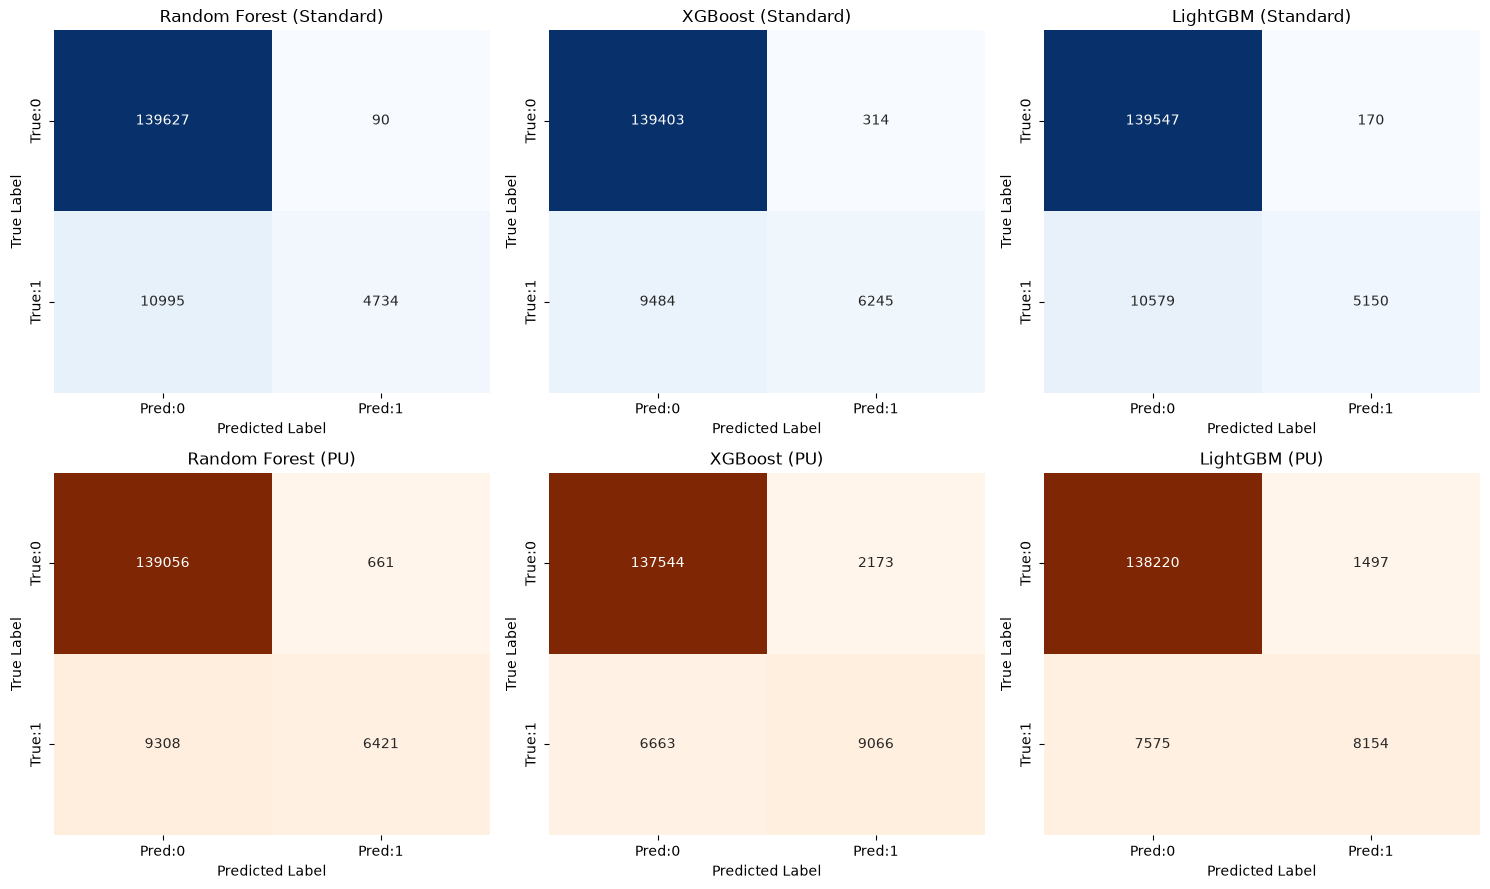

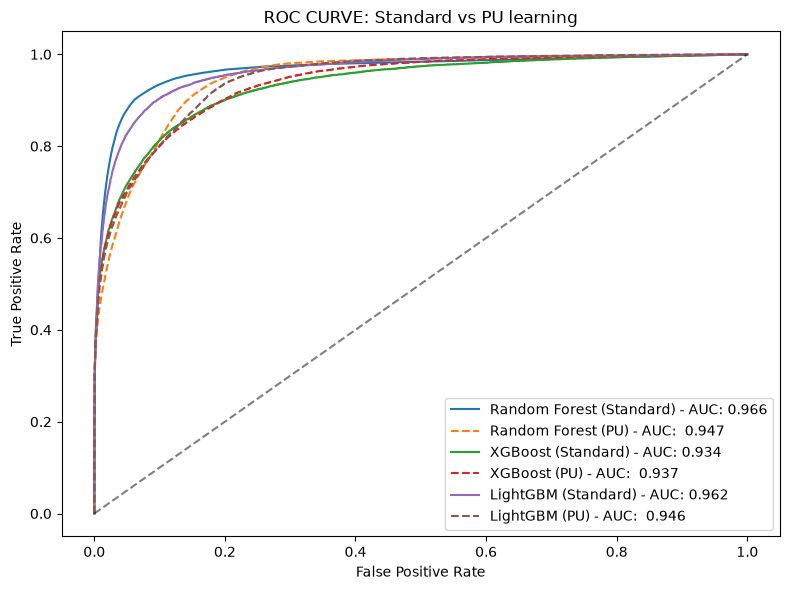

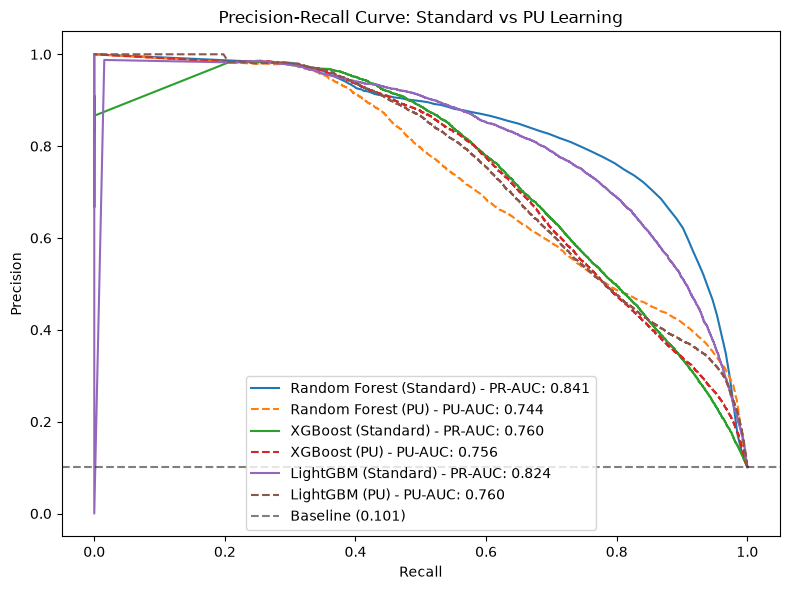

        Model        Type  Threshold  ROC-AUC  PR-AUC  Precision  Recall  F1-Score
Random Forest    Standard        0.9   0.9661  0.8413     0.9813  0.3010    0.4607
Random Forest PU Learning        0.9   0.9467  0.7438     0.9067  0.4082    0.5630
      XGBoost    Standard        0.9   0.9337  0.7600     0.9521  0.3970    0.5604
      XGBoost PU Learning        0.9   0.9373  0.7556     0.8067  0.5764    0.6724
     LightGBM    Standard        0.9   0.9622  0.8240     0.9680  0.3274    0.4893
     LightGBM PU Learning        0.9   0.9456  0.7604     0.8449  0.5184    0.6426


In [9]:
#=================
base_models = {
    "Random Forest":RandomForestClassifier(
    random_state=42
),
"XGBoost": xgb.XGBClassifier(
    random_state=42
),
"LightGBM":lgb.LGBMClassifier(
    random_state = 42,
)
} 
threshold = 0.9
results =[]
fig_cm, axes_cm = plt.subplots(2, 3, figsize=(15, 9))
fig_roc, ax_roc = plt.subplots(figsize=(8,6))
fig_prc, ax_prc = plt.subplots(figsize=(8,6)) # calculate PR-AUC / AP


for idx, (name, base_clf) in enumerate(base_models.items()):
    std_clf = clone(base_clf)
    std_clf.fit(X_train_final, y_train)

    y_prob_std= std_clf.predict_proba(X_test_final)[:, 1]
    y_pred_std = (y_prob_std >= threshold).astype(int)

    auc_std = roc_auc_score(y_test, y_prob_std)
    pr_auc_std = average_precision_score(y_test, y_prob_std)

    prec_std, rec_std, _ = precision_recall_curve(y_test, y_prob_std)
    ax_prc.plot(rec_std, prec_std, label=f'{name} (Standard) - PR-AUC: {pr_auc_std:.3f}')
    

    results.append({
        "Model":name, "Type":"Standard", "Threshold":threshold,
        "ROC-AUC": round(auc_std, 4),
        "PR-AUC": round(pr_auc_std, 4),
        "Precision": round(precision_score(y_test, y_pred_std, zero_division=0), 4),
        "Recall": round(recall_score(y_test, y_pred_std, zero_division=0), 4),
        "F1-Score": round(f1_score(y_test, y_pred_std, zero_division=0), 4)
    })

    fpr_std, tpr_std, _ = roc_curve(y_test, y_prob_std)
    ax_roc.plot(fpr_std, tpr_std, label=f"{name} (Standard) - AUC: {auc_std:.3f}")

    cm = confusion_matrix(y_test, y_pred_std)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes_cm[0, idx], cbar=False, xticklabels=['Pred:0','Pred:1'], yticklabels=['True:0', 'True:1'])

    axes_cm[0, idx].set_title(f"{name} (Standard)")
    axes_cm[0, idx].set_xlabel(f"Predicted Label")
    axes_cm[0, idx].set_ylabel(f"True Label")

    #============= Pu model
    n_bags= 30
    pu_clf= bagging_rf(n_bags,clone(base_clf), X_train_final, y_train)

    y_prob_pu = predict_proba_pu(pu_clf, X_test_final)
    y_pred_pu = (y_prob_pu >= threshold).astype(int)

    auc_pu = roc_auc_score(y_test, y_prob_pu)
    pr_auc_pu = average_precision_score(y_test, y_prob_pu)
    
    results.append({
        "Model": name, "Type": "PU Learning", "Threshold":threshold,
        "ROC-AUC": round(auc_pu, 4),
        "PR-AUC":round (pr_auc_pu, 4),
        "Precision": round(precision_score(y_test, y_pred_pu, zero_division=0), 4),
        "Recall": round(recall_score(y_test, y_pred_pu, zero_division=0), 4),
        "F1-Score": round(f1_score(y_test, y_pred_pu, zero_division=0 ), 4)
    })

    fpr_pu, tpr_pu, _ = roc_curve(y_test, y_prob_pu)
    ax_roc.plot(fpr_pu, tpr_pu, linestyle='--', label=f'{name} (PU) - AUC: {auc_pu: .3f}')

    prec_pu, rec_pu, _ = precision_recall_curve(y_test, y_prob_pu)
    ax_prc.plot(rec_pu, prec_pu, linestyle='--', label=f'{name} (PU) - PU-AUC:{pr_auc_pu: .3f}')

    cm = confusion_matrix(y_test, y_pred_pu)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes_cm[1, idx], cbar=False, xticklabels=['Pred:0','Pred:1'], yticklabels=['True:0', 'True:1'])
    axes_cm[1, idx].set_title(f"{name} (PU)")
    axes_cm[1, idx].set_xlabel("Predicted Label")
    axes_cm[1, idx].set_ylabel("True Label")

ax_roc.plot([0, 1], [0,1], 'k--', alpha=0.5)
ax_roc.set_title("ROC CURVE: Standard vs PU learning")
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.legend()

fig_roc.tight_layout()
fig_roc.savefig("img/PU_ROC_Comparison.png")



baseline_pr = np.sum(y_test == 1) / len(y_test)
ax_prc.axhline(y=baseline_pr, color='k', linestyle='--', alpha=0.5, label=f'Baseline ({baseline_pr:.3f})')
ax_prc.set_title("Precision-Recall Curve: Standard vs PU Learning")
ax_prc.set_xlabel("Recall")
ax_prc.set_ylabel("Precision")
ax_prc.legend()
fig_prc.tight_layout()
fig_prc.savefig("img/PU_PRC_Comparison.png")


fig_cm.tight_layout()
fig_cm.savefig("img/PU_Confusion_Matrix_Comparison.png")


plt.show()


df_metrics = pd.DataFrame(results)
print(df_metrics.to_string(index=False))
df_metrics.to_csv("img/PU_vs_Standard_Metrics.csv", index=False)
#===========

Maybe threshold 0.9 is too high?


### grids search bags start from 5


 Grid Search:Random Forest
Fitting 3 folds for each of 2 candidates, totalling 6 fits
[CV] END .....................max_depth=10, n_estimators=100; total time=  19.3s
[CV] END .....................max_depth=10, n_estimators=100; total time=  19.4s
[CV] END .....................max_depth=10, n_estimators=100; total time=  19.5s
[CV] END .....................max_depth=20, n_estimators=100; total time=  35.6s
[CV] END .....................max_depth=20, n_estimators=100; total time=  35.8s
[CV] END .....................max_depth=20, n_estimators=100; total time=  36.0s
Best parameter combination: {'max_depth': 20, 'n_estimators': 100}
Number of Bag: 5
Positive: 21442
Unlabeled: 600338

 PU training data, Bag 1/5 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 2/5 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 3/5 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 4/5 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 5/5 Positive = 21442, Unlabele

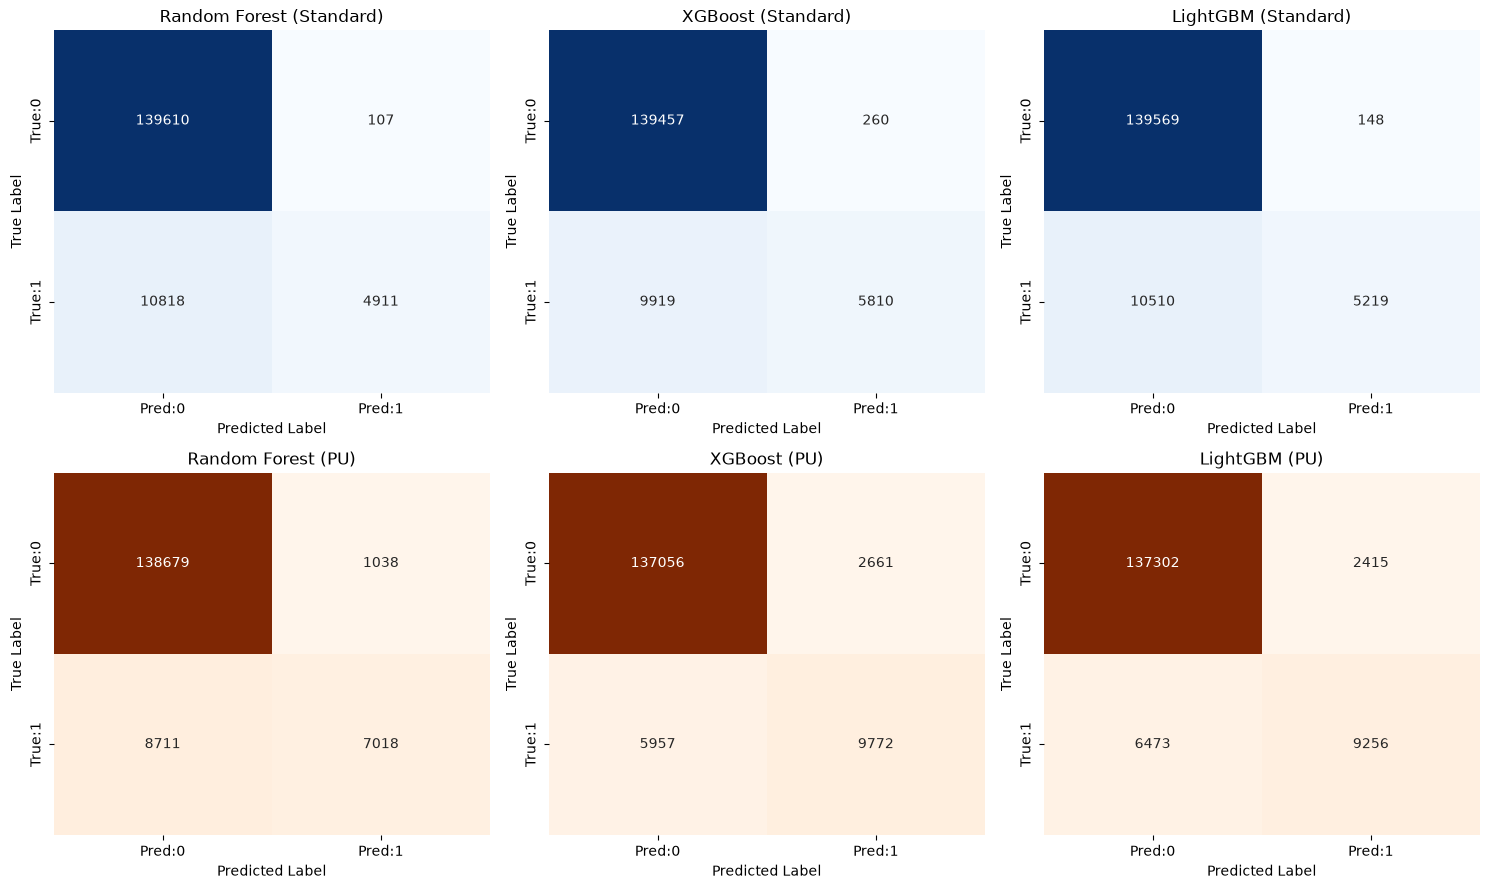

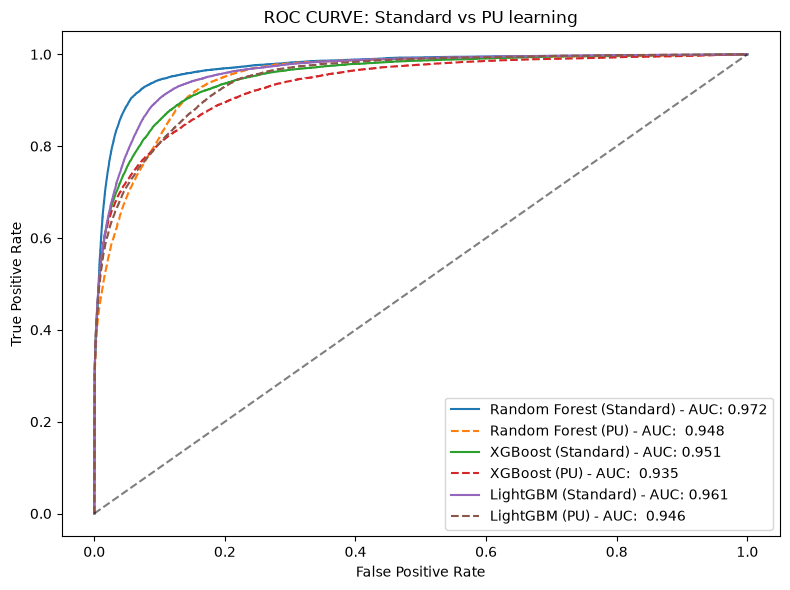

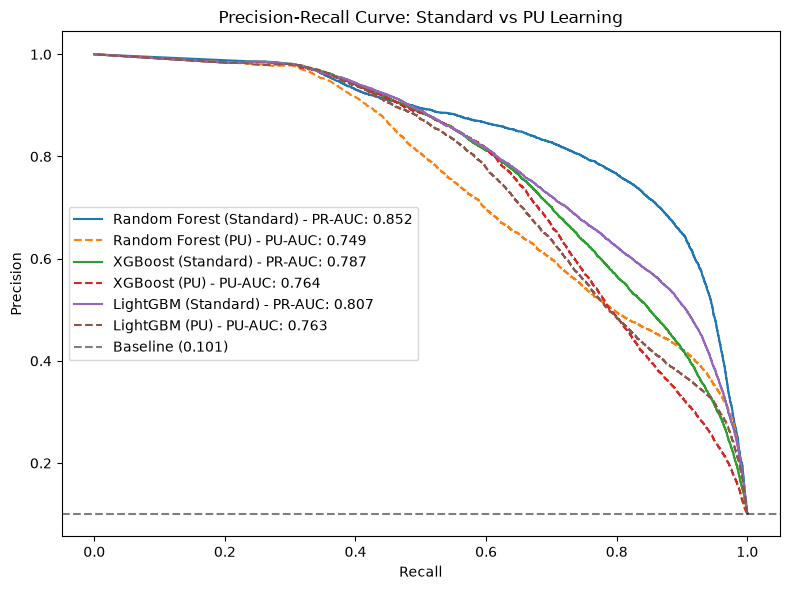

        Model        Type  Threshold  ROC-AUC  PR-AUC  Precision  Recall  F1-Score
Random Forest    Standard       0.85   0.9720  0.8516     0.9787  0.3122    0.4734
Random Forest PU Learning       0.85   0.9483  0.7486     0.8712  0.4462    0.5901
      XGBoost    Standard       0.85   0.9507  0.7872     0.9572  0.3694    0.5331
      XGBoost PU Learning       0.85   0.9349  0.7638     0.7860  0.6213    0.6940
     LightGBM    Standard       0.85   0.9612  0.8065     0.9724  0.3318    0.4948
     LightGBM PU Learning       0.85   0.9457  0.7634     0.7931  0.5885    0.6756


In [12]:

#=================
param_grids = {
    "Random Forest":{
        'n_estimators':[100],
        'max_depth': [10, 20],
        #'min_samples_split':[2, 5],
        #'class_weight':['balanced']
        },
    "XGBoost":{
        'n_estimators':[100, 200],
        'max_depth':[3, 5],
        'learning_rate':[0.05, 0.1]
       # 'subample':[0.8],
        #'colsample_bytree':[0.8]
        },
    "LightGBM":{
        'n_estimators':[100, 200],
        'max_depth':[-1, 10],
        'learning_rate':[0.05, 0.1],
        #'verbose':[-1]
    }
}
base_models = {
    "Random Forest":RandomForestClassifier(random_state=42),
    "XGBoost":xgb.XGBClassifier(random_state=42),
    "LightGBM":lgb.LGBMClassifier(random_state = 42)
} 

threshold = 0.85
results =[]
fig_cm, axes_cm = plt.subplots(2, 3, figsize=(15, 9))
fig_roc, ax_roc = plt.subplots(figsize=(8,6))
fig_prc, ax_prc = plt.subplots(figsize=(8,6)) # calculate PR-AUC / AP
best_fitted_models = {}
best_params_dict = {}
best_score_dict = {}

for idx, (name, base_clf) in enumerate(base_models.items()):
    print(f" Grid Search:{name}")
    X_sub, _, y_sub, _ = train_test_split(
        X_train_final, y_train,
        train_size=0.1,
        random_state=42,
        stratify=y_train
    )
    grid_search = GridSearchCV(
        estimator = clone(base_clf),
        param_grid = param_grids[name],
        cv = 3,
        scoring = 'average_precision',
        n_jobs=-1,
        verbose=2
        
    )
    grid_search.fit(X_sub, y_sub)

    best_params= grid_search.best_params_
    best_params_dict[name] = grid_search.best_params_
    best_score_dict[name] = grid_search.best_score_
    
    print(f"Best parameter combination: {best_params}")
    best_std_clf = clone(base_clf)
    best_std_clf.set_params(**best_params)
    best_std_clf.fit(X_train_final, y_train)

    best_fitted_models[name] = best_std_clf
    y_prob_std= best_std_clf.predict_proba(X_test_final)[:, 1]
    y_pred_std = (y_prob_std >= threshold).astype(int)

    auc_std = roc_auc_score(y_test, y_prob_std)
    pr_auc_std = average_precision_score(y_test, y_prob_std)

    prec_std, rec_std, _ = precision_recall_curve(y_test, y_prob_std)
    ax_prc.plot(rec_std, prec_std, label=f'{name} (Standard) - PR-AUC: {pr_auc_std:.3f}')
    

    results.append({
        "Model":name, "Type":"Standard", "Threshold":threshold,
        "ROC-AUC": round(auc_std, 4),
        "PR-AUC": round(pr_auc_std, 4),
        "Precision": round(precision_score(y_test, y_pred_std, zero_division=0), 4),
        "Recall": round(recall_score(y_test, y_pred_std, zero_division=0), 4),
        "F1-Score": round(f1_score(y_test, y_pred_std, zero_division=0), 4)
    })

    fpr_std, tpr_std, _ = roc_curve(y_test, y_prob_std)
    ax_roc.plot(fpr_std, tpr_std, label=f"{name} (Standard) - AUC: {auc_std:.3f}")

    cm = confusion_matrix(y_test, y_pred_std)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes_cm[0, idx], cbar=False, xticklabels=['Pred:0','Pred:1'], yticklabels=['True:0', 'True:1'])

    axes_cm[0, idx].set_title(f"{name} (Standard)")
    axes_cm[0, idx].set_xlabel(f"Predicted Label")
    axes_cm[0, idx].set_ylabel(f"True Label")

    #============= Pu model
    n_bags= 5
    pu_clf= bagging_rf(n_bags,clone(best_std_clf), X_train_final, y_train)

    y_prob_pu = predict_proba_pu(pu_clf, X_test_final)
    y_pred_pu = (y_prob_pu >= threshold).astype(int)

    auc_pu = roc_auc_score(y_test, y_prob_pu)
    pr_auc_pu = average_precision_score(y_test, y_prob_pu)
    
    results.append({
        "Model": name, "Type": "PU Learning", "Threshold":threshold,
        "ROC-AUC": round(auc_pu, 4),
        "PR-AUC":round (pr_auc_pu, 4),
        "Precision": round(precision_score(y_test, y_pred_pu, zero_division=0), 4),
        "Recall": round(recall_score(y_test, y_pred_pu, zero_division=0), 4),
        "F1-Score": round(f1_score(y_test, y_pred_pu, zero_division=0 ), 4)
    })

    fpr_pu, tpr_pu, _ = roc_curve(y_test, y_prob_pu)
    ax_roc.plot(fpr_pu, tpr_pu, linestyle='--', label=f'{name} (PU) - AUC: {auc_pu: .3f}')

    prec_pu, rec_pu, _ = precision_recall_curve(y_test, y_prob_pu)
    ax_prc.plot(rec_pu, prec_pu, linestyle='--', label=f'{name} (PU) - PU-AUC:{pr_auc_pu: .3f}')

    cm = confusion_matrix(y_test, y_pred_pu)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes_cm[1, idx], cbar=False, xticklabels=['Pred:0','Pred:1'], yticklabels=['True:0', 'True:1'])
    axes_cm[1, idx].set_title(f"{name} (PU)")
    axes_cm[1, idx].set_xlabel("Predicted Label")
    axes_cm[1, idx].set_ylabel("True Label")

ax_roc.plot([0, 1], [0,1], 'k--', alpha=0.5)
ax_roc.set_title("ROC CURVE: Standard vs PU learning")
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.legend()

fig_roc.tight_layout()
fig_roc.savefig("img/PU_ROC_Comparison.png")



baseline_pr = np.sum(y_test == 1) / len(y_test)
ax_prc.axhline(y=baseline_pr, color='k', linestyle='--', alpha=0.5, label=f'Baseline ({baseline_pr:.3f})')
ax_prc.set_title("Precision-Recall Curve: Standard vs PU Learning")
ax_prc.set_xlabel("Recall")
ax_prc.set_ylabel("Precision")
ax_prc.legend()
fig_prc.tight_layout()
fig_prc.savefig("img/PU_PRC_Comparison_grid_bag5.png")


fig_cm.tight_layout()
fig_cm.savefig("img/PU_Confusion_Matrix_Comparison_grid_bag5.png")


plt.show()


df_metrics = pd.DataFrame(results)
print(df_metrics.to_string(index=False))
df_metrics.to_csv("img/PU_vs_Standard_Metrics_grid_bag5.csv", index=False)
#===========


RF model peroforms well, set param as {'max_depth': 20, 'n_estimators': 100}
lighBGM takes time,
tuning XGBOost first( it runs fast)


### hypertuning xgboost

 Grid Search:XGBoost
Fitting 3 folds for each of 9 candidates, totalling 27 fits
[CV] END ...learning_rate=0.1, max_depth=4, n_estimators=150; total time=   1.4s
[CV] END ...learning_rate=0.1, max_depth=4, n_estimators=150; total time=   1.5s
[CV] END ...learning_rate=0.1, max_depth=4, n_estimators=150; total time=   1.5s
[CV] END ...learning_rate=0.1, max_depth=4, n_estimators=200; total time=   2.0s
[CV] END ...learning_rate=0.1, max_depth=4, n_estimators=200; total time=   2.0s
[CV] END ...learning_rate=0.1, max_depth=4, n_estimators=200; total time=   2.1s
[CV] END ...learning_rate=0.1, max_depth=5, n_estimators=150; total time=   2.6s
[CV] END ...learning_rate=0.1, max_depth=5, n_estimators=150; total time=   2.4s
[CV] END ...learning_rate=0.1, max_depth=5, n_estimators=150; total time=   2.7s
[CV] END ...learning_rate=0.1, max_depth=4, n_estimators=300; total time=   3.4s
[CV] END ...learning_rate=0.1, max_depth=4, n_estimators=300; total time=   3.5s
[CV] END ...learning_rate=0.

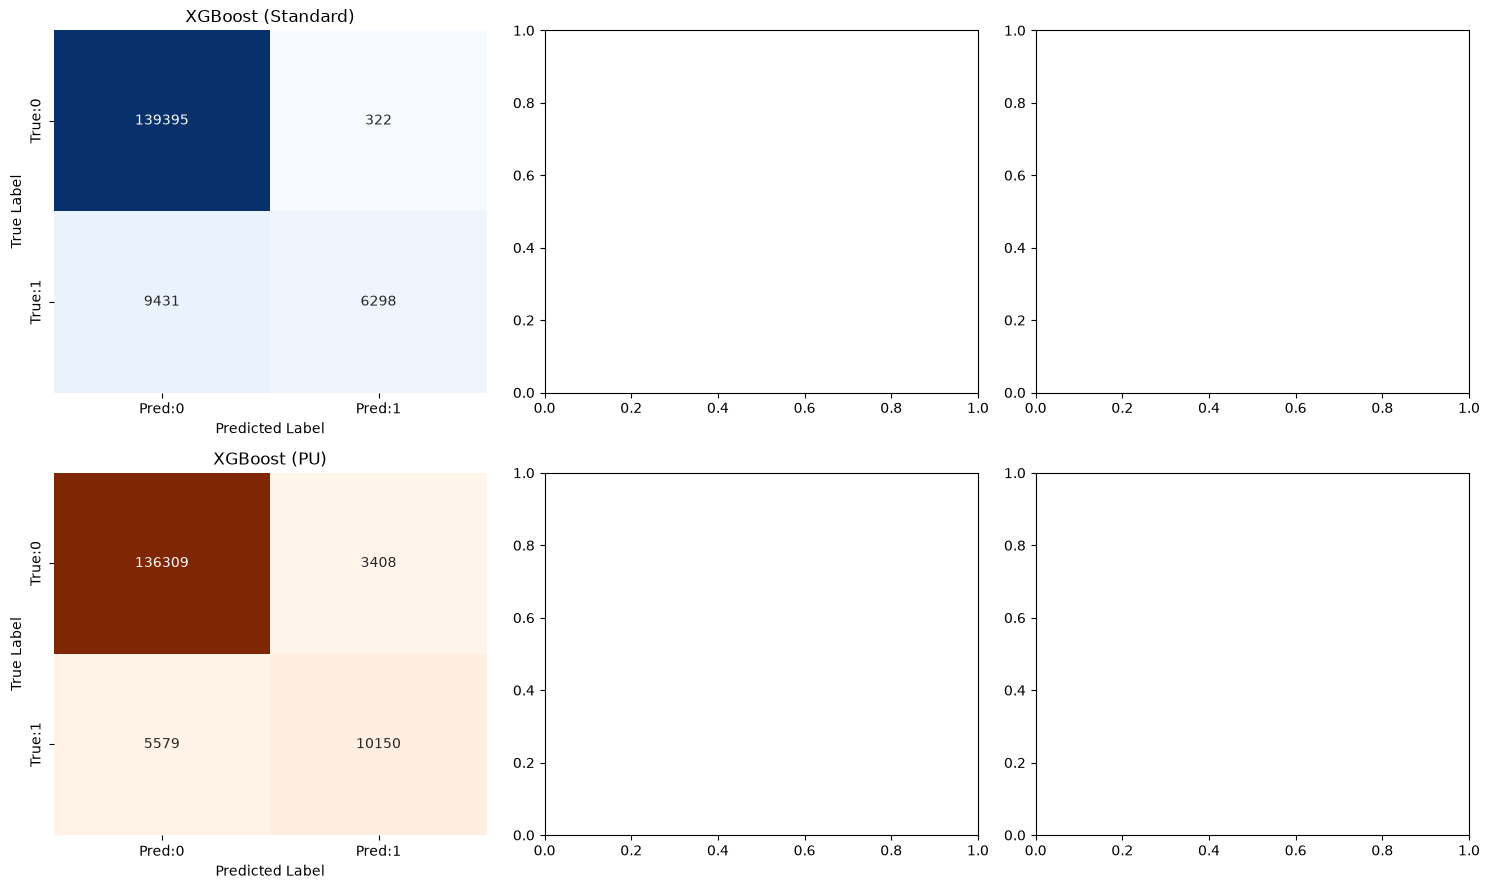

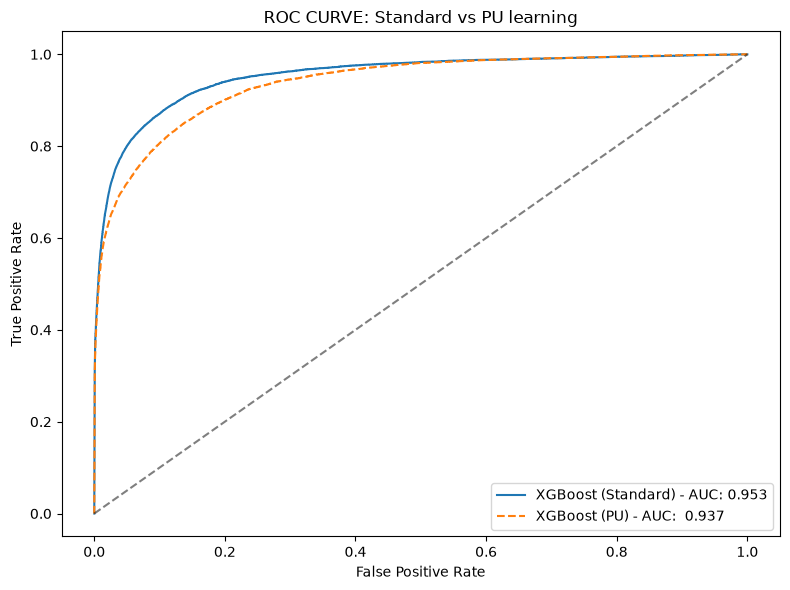

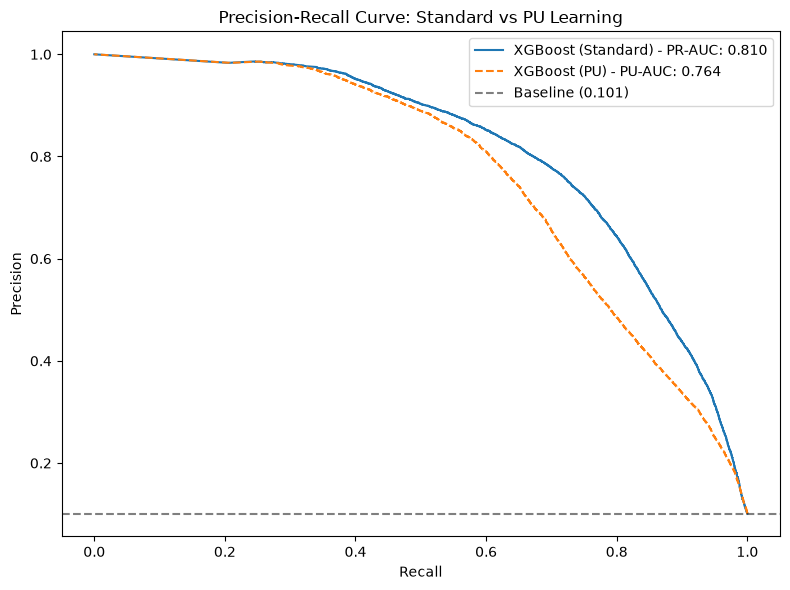

  Model        Type  Threshold  ROC-AUC  PR-AUC  Precision  Recall  F1-Score
XGBoost    Standard       0.85   0.9532  0.8101     0.9514  0.4004    0.5636
XGBoost PU Learning       0.85   0.9369  0.7641     0.7486  0.6453    0.6931


In [13]:

#=================
param_grids = {
    "Random Forest":{
        'n_estimators':[100],
        'max_depth': [10, 20],
        #'min_samples_split':[2, 5],
        #'class_weight':['balanced']
        },
    "XGBoost":{
        'n_estimators':[150, 200, 300],
        'max_depth':[4, 5, 6],
        'learning_rate':[0.1]
       # 'subample':[0.8],
        #'colsample_bytree':[0.8]
        },
    "LightGBM":{
        'n_estimators':[100, 200],
        'max_depth':[-1, 10],
        'learning_rate':[0.05, 0.1],
        #'verbose':[-1]
    }
}

base_models = {
    #"Random Forest":RandomForestClassifier(random_state=42),
    "XGBoost":xgb.XGBClassifier(random_state=42),
    #"LightGBM":lgb.LGBMClassifier(random_state = 42)
} 

#================
threshold = 0.85
results =[]
fig_cm, axes_cm = plt.subplots(2, 3, figsize=(15, 9))
fig_roc, ax_roc = plt.subplots(figsize=(8,6))
fig_prc, ax_prc = plt.subplots(figsize=(8,6)) # calculate PR-AUC / AP
best_fitted_models = {}
best_params_dict = {}
best_score_dict = {}

for idx, (name, base_clf) in enumerate(base_models.items()):
    print(f" Grid Search:{name}")
    X_sub, _, y_sub, _ = train_test_split(
        X_train_final, y_train,
        train_size=0.1,
        random_state=42,
        stratify=y_train
    )
    grid_search = GridSearchCV(
        estimator = clone(base_clf),
        param_grid = param_grids[name],
        cv = 3,
        scoring = 'average_precision',
        n_jobs=-1,
        verbose=2
        
    )
    grid_search.fit(X_sub, y_sub)

    best_params= grid_search.best_params_
    best_params_dict[name] = grid_search.best_params_
    best_score_dict[name] = grid_search.best_score_
    
    print(f"Best parameter combination: {best_params}")
    best_std_clf = clone(base_clf)
    best_std_clf.set_params(**best_params)
    best_std_clf.fit(X_train_final, y_train)

    best_fitted_models[name] = best_std_clf
    y_prob_std= best_std_clf.predict_proba(X_test_final)[:, 1]
    y_pred_std = (y_prob_std >= threshold).astype(int)

    auc_std = roc_auc_score(y_test, y_prob_std)
    pr_auc_std = average_precision_score(y_test, y_prob_std)

    prec_std, rec_std, _ = precision_recall_curve(y_test, y_prob_std)
    ax_prc.plot(rec_std, prec_std, label=f'{name} (Standard) - PR-AUC: {pr_auc_std:.3f}')
    

    results.append({
        "Model":name, "Type":"Standard", "Threshold":threshold,
        "ROC-AUC": round(auc_std, 4),
        "PR-AUC": round(pr_auc_std, 4),
        "Precision": round(precision_score(y_test, y_pred_std, zero_division=0), 4),
        "Recall": round(recall_score(y_test, y_pred_std, zero_division=0), 4),
        "F1-Score": round(f1_score(y_test, y_pred_std, zero_division=0), 4)
    })

    fpr_std, tpr_std, _ = roc_curve(y_test, y_prob_std)
    ax_roc.plot(fpr_std, tpr_std, label=f"{name} (Standard) - AUC: {auc_std:.3f}")

    cm = confusion_matrix(y_test, y_pred_std)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes_cm[0, idx], cbar=False, xticklabels=['Pred:0','Pred:1'], yticklabels=['True:0', 'True:1'])

    axes_cm[0, idx].set_title(f"{name} (Standard)")
    axes_cm[0, idx].set_xlabel(f"Predicted Label")
    axes_cm[0, idx].set_ylabel(f"True Label")

    #============= Pu model
    n_bags= 5
    pu_clf= bagging_rf(n_bags,clone(best_std_clf), X_train_final, y_train)

    y_prob_pu = predict_proba_pu(pu_clf, X_test_final)
    y_pred_pu = (y_prob_pu >= threshold).astype(int)

    auc_pu = roc_auc_score(y_test, y_prob_pu)
    pr_auc_pu = average_precision_score(y_test, y_prob_pu)
    
    results.append({
        "Model": name, "Type": "PU Learning", "Threshold":threshold,
        "ROC-AUC": round(auc_pu, 4),
        "PR-AUC":round (pr_auc_pu, 4),
        "Precision": round(precision_score(y_test, y_pred_pu, zero_division=0), 4),
        "Recall": round(recall_score(y_test, y_pred_pu, zero_division=0), 4),
        "F1-Score": round(f1_score(y_test, y_pred_pu, zero_division=0 ), 4)
    })

    fpr_pu, tpr_pu, _ = roc_curve(y_test, y_prob_pu)
    ax_roc.plot(fpr_pu, tpr_pu, linestyle='--', label=f'{name} (PU) - AUC: {auc_pu: .3f}')

    prec_pu, rec_pu, _ = precision_recall_curve(y_test, y_prob_pu)
    ax_prc.plot(rec_pu, prec_pu, linestyle='--', label=f'{name} (PU) - PU-AUC:{pr_auc_pu: .3f}')

    cm = confusion_matrix(y_test, y_pred_pu)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes_cm[1, idx], cbar=False, xticklabels=['Pred:0','Pred:1'], yticklabels=['True:0', 'True:1'])
    axes_cm[1, idx].set_title(f"{name} (PU)")
    axes_cm[1, idx].set_xlabel("Predicted Label")
    axes_cm[1, idx].set_ylabel("True Label")

ax_roc.plot([0, 1], [0,1], 'k--', alpha=0.5)
ax_roc.set_title("ROC CURVE: Standard vs PU learning")
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.legend()

fig_roc.tight_layout()
fig_roc.savefig("img/PU_ROC_Comparison_XGBOOST.png")



baseline_pr = np.sum(y_test == 1) / len(y_test)
ax_prc.axhline(y=baseline_pr, color='k', linestyle='--', alpha=0.5, label=f'Baseline ({baseline_pr:.3f})')
ax_prc.set_title("Precision-Recall Curve: Standard vs PU Learning")
ax_prc.set_xlabel("Recall")
ax_prc.set_ylabel("Precision")
ax_prc.legend()
fig_prc.tight_layout()
fig_prc.savefig("img/PU_PRC_Comparison_grid_bag5_XGBOOST.png")


fig_cm.tight_layout()
fig_cm.savefig("img/PU_Confusion_Matrix_Comparison_grid_bag5_XGBOOST.png")


plt.show()


df_metrics = pd.DataFrame(results)
print(df_metrics.to_string(index=False))
df_metrics.to_csv("img/PU_vs_Standard_Metrics_grid_bag5_XGBOOST.csv", index=False)
#===========Rf model 

### Different bags - with XGBOOST best param 

 Grid Search:XGBoost
Fitting 3 folds for each of 9 candidates, totalling 27 fits
[CV] END ...learning_rate=0.1, max_depth=4, n_estimators=150; total time=   1.7s
[CV] END ...learning_rate=0.1, max_depth=4, n_estimators=150; total time=   1.7s
[CV] END ...learning_rate=0.1, max_depth=4, n_estimators=150; total time=   1.8s
[CV] END ...learning_rate=0.1, max_depth=4, n_estimators=200; total time=   2.2s
[CV] END ...learning_rate=0.1, max_depth=4, n_estimators=200; total time=   2.2s
[CV] END ...learning_rate=0.1, max_depth=4, n_estimators=200; total time=   2.4s
[CV] END ...learning_rate=0.1, max_depth=5, n_estimators=150; total time=   2.8s
[CV] END ...learning_rate=0.1, max_depth=5, n_estimators=150; total time=   2.6s
[CV] END ...learning_rate=0.1, max_depth=5, n_estimators=150; total time=   2.8s
[CV] END ...learning_rate=0.1, max_depth=4, n_estimators=300; total time=   3.4s
[CV] END ...learning_rate=0.1, max_depth=5, n_estimators=200; total time=   3.0s
[CV] END ...learning_rate=0.

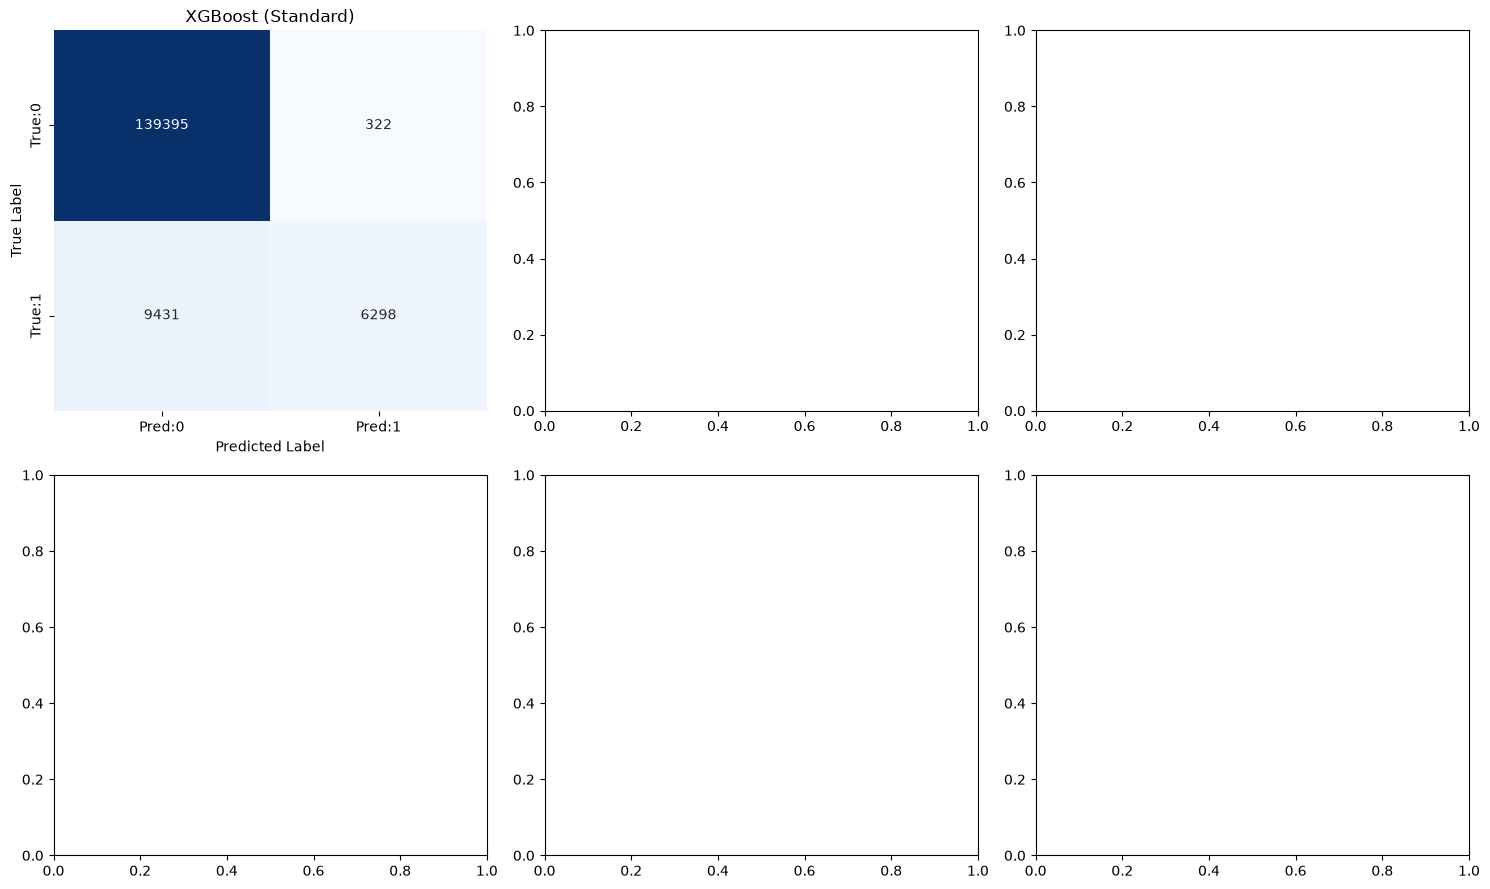

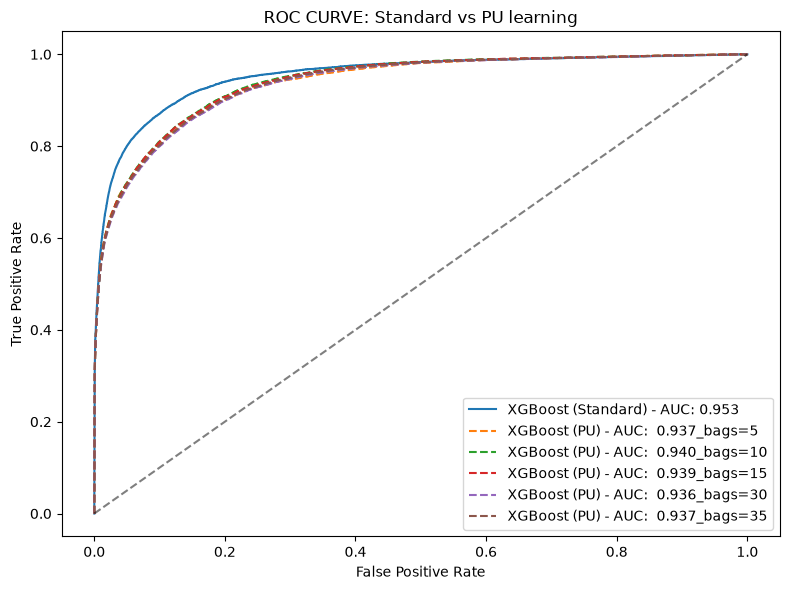

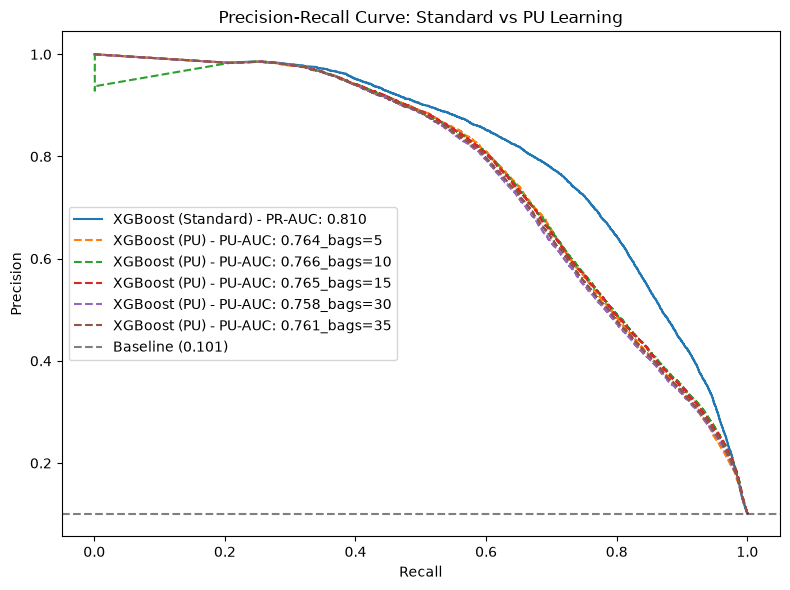

  Model        Type  Threshold  Bag  ROC-AUC  PR-AUC  Precision  Recall  F1-Score
XGBoost    Standard       0.85    0   0.9532  0.8101     0.9514  0.4004    0.5636
XGBoost PU Learning       0.85    5   0.9369  0.7641     0.7486  0.6453    0.6931
XGBoost PU Learning       0.85   10   0.9400  0.7662     0.7493  0.6421    0.6915
XGBoost PU Learning       0.85   15   0.9393  0.7653     0.7504  0.6386    0.6900
XGBoost PU Learning       0.85   30   0.9360  0.7584     0.7467  0.6313    0.6842
XGBoost PU Learning       0.85   35   0.9374  0.7611     0.7485  0.6338    0.6864


In [14]:

#=================
n_bags=0
param_grids = {
    "Random Forest":{
        'n_estimators':[100],
        'max_depth': [10, 20],
        #'min_samples_split':[2, 5],
        #'class_weight':['balanced']
        },
    "XGBoost":{
        'n_estimators':[150, 200, 300],
        'max_depth':[4, 5, 6],
        'learning_rate':[0.1]
       # 'subample':[0.8],
        #'colsample_bytree':[0.8]
        },
    "LightGBM":{
        'n_estimators':[100, 200],
        'max_depth':[-1, 10],
        'learning_rate':[0.05, 0.1],
        #'verbose':[-1]
    }
}
base_models = {
    #"Random Forest":RandomForestClassifier(random_state=42),
    "XGBoost":xgb.XGBClassifier(random_state=42),
    #"LightGBM":lgb.LGBMClassifier(random_state = 42)
} 

threshold = 0.85
results =[]
fig_cm, axes_cm = plt.subplots(2, 3, figsize=(15, 9))
fig_roc, ax_roc = plt.subplots(figsize=(8,6))
fig_prc, ax_prc = plt.subplots(figsize=(8,6)) # calculate PR-AUC / AP
best_fitted_models = {}
best_params_dict = {}
best_score_dict = {}

for idx, (name, base_clf) in enumerate(base_models.items()):
    print(f" Grid Search:{name}")
    X_sub, _, y_sub, _ = train_test_split(
        X_train_final, y_train,
        train_size=0.1,
        random_state=42,
        stratify=y_train
    )
    grid_search = GridSearchCV(
        estimator = clone(base_clf),
        param_grid = param_grids[name],
        cv = 3,
        scoring = 'average_precision',
        n_jobs=-1,
        verbose=2
        
    )
    grid_search.fit(X_sub, y_sub)

    best_params= grid_search.best_params_
    best_params_dict[name] = grid_search.best_params_
    best_score_dict[name] = grid_search.best_score_
    
    print(f"Best parameter combination: {best_params}")
    best_std_clf = clone(base_clf)
    best_std_clf.set_params(**best_params)
    best_std_clf.fit(X_train_final, y_train)

    best_fitted_models[name] = best_std_clf
    y_prob_std= best_std_clf.predict_proba(X_test_final)[:, 1]
    y_pred_std = (y_prob_std >= threshold).astype(int)

    auc_std = roc_auc_score(y_test, y_prob_std)
    pr_auc_std = average_precision_score(y_test, y_prob_std)

    prec_std, rec_std, _ = precision_recall_curve(y_test, y_prob_std)
    ax_prc.plot(rec_std, prec_std, label=f'{name} (Standard) - PR-AUC: {pr_auc_std:.3f}')
    

    results.append({
        "Model":name, "Type":"Standard", "Threshold":threshold,"Bag":n_bags,
        "ROC-AUC": round(auc_std, 4),
        "PR-AUC": round(pr_auc_std, 4),
        "Precision": round(precision_score(y_test, y_pred_std, zero_division=0), 4),
        "Recall": round(recall_score(y_test, y_pred_std, zero_division=0), 4),
        "F1-Score": round(f1_score(y_test, y_pred_std, zero_division=0), 4)
    })

    fpr_std, tpr_std, _ = roc_curve(y_test, y_prob_std)
    ax_roc.plot(fpr_std, tpr_std, label=f"{name} (Standard) - AUC: {auc_std:.3f}")

    cm = confusion_matrix(y_test, y_pred_std)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes_cm[0, idx], cbar=False, xticklabels=['Pred:0','Pred:1'], yticklabels=['True:0', 'True:1'])

    axes_cm[0, idx].set_title(f"{name} (Standard)")
    axes_cm[0, idx].set_xlabel(f"Predicted Label")
    axes_cm[0, idx].set_ylabel(f"True Label")

    #============= Pu model
    bag_list = [5, 10, 15, 30, 35]
    for n_bags in bag_list:
        pu_clf= bagging_rf(n_bags,clone(best_std_clf), X_train_final, y_train)

        y_prob_pu = predict_proba_pu(pu_clf, X_test_final)
        y_pred_pu = (y_prob_pu >= threshold).astype(int)

        auc_pu = roc_auc_score(y_test, y_prob_pu)
        pr_auc_pu = average_precision_score(y_test, y_prob_pu)
        
        results.append({
            "Model": name, "Type": "PU Learning", "Threshold":threshold,"Bag":n_bags,
            "ROC-AUC": round(auc_pu, 4),
            "PR-AUC":round (pr_auc_pu, 4),
            "Precision": round(precision_score(y_test, y_pred_pu, zero_division=0), 4),
            "Recall": round(recall_score(y_test, y_pred_pu, zero_division=0), 4),
            "F1-Score": round(f1_score(y_test, y_pred_pu, zero_division=0 ), 4)
        })

        fpr_pu, tpr_pu, _ = roc_curve(y_test, y_prob_pu)
        ax_roc.plot(fpr_pu, tpr_pu, linestyle='--', label=f'{name} (PU) - AUC: {auc_pu: .3f}_bags={n_bags}')

        prec_pu, rec_pu, _ = precision_recall_curve(y_test, y_prob_pu)
        ax_prc.plot(rec_pu, prec_pu, linestyle='--', label=f'{name} (PU) - PU-AUC:{pr_auc_pu: .3f}_bags={n_bags}')

    #cm = confusion_matrix(y_test, y_pred_pu)
    #sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes_cm[1, idx], cbar=False, xticklabels=['Pred:0','Pred:1'], yticklabels=['True:0', 'True:1'])
    #xes_cm[1, idx].set_title(f"{name} (PU)")
    #axes_cm[1, idx].set_xlabel("Predicted Label")
    #axes_cm[1, idx].set_ylabel("True Label")

ax_roc.plot([0, 1], [0,1], 'k--', alpha=0.5)
ax_roc.set_title("ROC CURVE: Standard vs PU learning")
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.legend()

fig_roc.tight_layout()
fig_roc.savefig("img/PU_ROC_Comparison_XGBOOST_bag_compar.png")



baseline_pr = np.sum(y_test == 1) / len(y_test)
ax_prc.axhline(y=baseline_pr, color='k', linestyle='--', alpha=0.5, label=f'Baseline ({baseline_pr:.3f})')
ax_prc.set_title("Precision-Recall Curve: Standard vs PU Learning")
ax_prc.set_xlabel("Recall")
ax_prc.set_ylabel("Precision")
ax_prc.legend()
fig_prc.tight_layout()
fig_prc.savefig("img/PU_PRC_Comparison_XGBOOST_bag_compar.png")


fig_cm.tight_layout()
fig_cm.savefig("img/PU_Confusion_Matrix_Comparison_XGBOOST_bag_compar.png")


plt.show()


df_metrics = pd.DataFrame(results)
print(df_metrics.to_string(index=False))
df_metrics.to_csv("img/PU_vs_Standard_Metrics_XGBOOST_bag_compar.csv", index=False)
#===========Rf model 

### 30 bags with XGBoost try different threshold

 Grid Search:XGBoost
Fitting 3 folds for each of 9 candidates, totalling 27 fits
[CV] END ...learning_rate=0.1, max_depth=4, n_estimators=150; total time=   1.7s
[CV] END ...learning_rate=0.1, max_depth=4, n_estimators=150; total time=   1.8s
[CV] END ...learning_rate=0.1, max_depth=4, n_estimators=150; total time=   1.7s
[CV] END ...learning_rate=0.1, max_depth=4, n_estimators=200; total time=   2.4s
[CV] END ...learning_rate=0.1, max_depth=4, n_estimators=200; total time=   2.5s
[CV] END ...learning_rate=0.1, max_depth=4, n_estimators=200; total time=   2.6s
[CV] END ...learning_rate=0.1, max_depth=5, n_estimators=150; total time=   2.5s
[CV] END ...learning_rate=0.1, max_depth=5, n_estimators=150; total time=   2.8s
[CV] END ...learning_rate=0.1, max_depth=5, n_estimators=150; total time=   3.1s
[CV] END ...learning_rate=0.1, max_depth=4, n_estimators=300; total time=   3.7s
[CV] END ...learning_rate=0.1, max_depth=4, n_estimators=300; total time=   3.9s
[CV] END ...learning_rate=0.

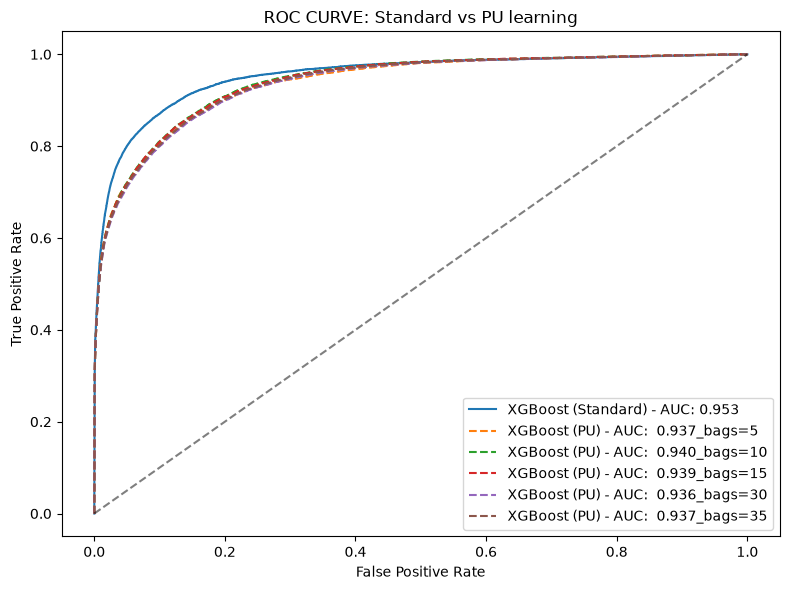

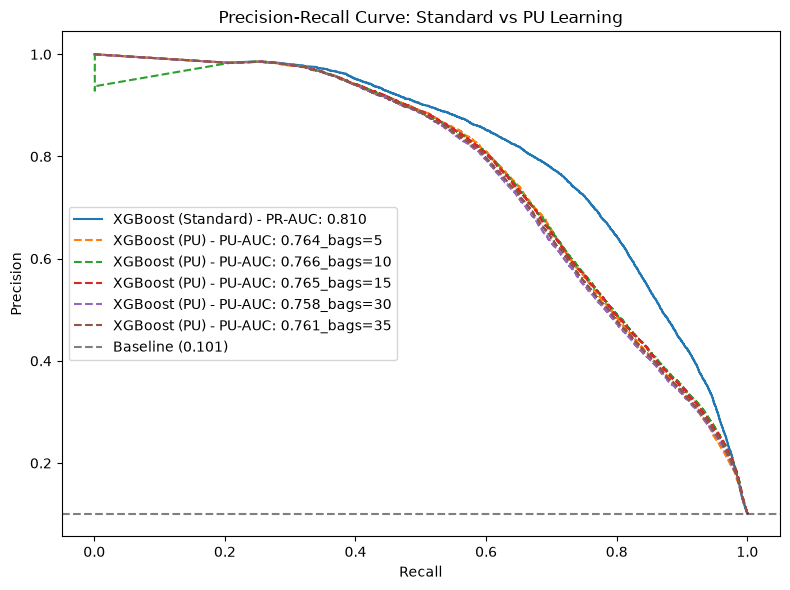

  Model        Type  Threshold  Bag  ROC-AUC  PR-AUC  Precision  Recall  F1-Score
XGBoost    Standard       0.50    0   0.9532  0.8101     0.8834  0.5455    0.6745
XGBoost    Standard       0.51    0   0.9532  0.8101     0.8860  0.5417    0.6723
XGBoost    Standard       0.52    0   0.9532  0.8101     0.8878  0.5368    0.6691
XGBoost    Standard       0.53    0   0.9532  0.8101     0.8889  0.5326    0.6661
XGBoost    Standard       0.54    0   0.9532  0.8101     0.8911  0.5285    0.6635
XGBoost    Standard       0.55    0   0.9532  0.8101     0.8926  0.5249    0.6611
XGBoost    Standard       0.56    0   0.9532  0.8101     0.8946  0.5209    0.6585
XGBoost    Standard       0.57    0   0.9532  0.8101     0.8960  0.5168    0.6555
XGBoost    Standard       0.58    0   0.9532  0.8101     0.8986  0.5127    0.6529
XGBoost    Standard       0.59    0   0.9532  0.8101     0.8999  0.5078    0.6492
XGBoost    Standard       0.60    0   0.9532  0.8101     0.9010  0.5036    0.6461
XGBoost    Stand

In [15]:
#=================
n_bags=0
param_grids = {
    "Random Forest":{
        'n_estimators':[100],
        'max_depth': [10, 20],
        #'min_samples_split':[2, 5],
        #'class_weight':['balanced']
        },
    "XGBoost":{
        'n_estimators':[150, 200, 300],
        'max_depth':[4, 5, 6],
        'learning_rate':[0.1]
       # 'subample':[0.8],
        #'colsample_bytree':[0.8]
        },
    "LightGBM":{
    'learning_rate': 0.1, 
    'max_depth': 6, 
    'n_estimators': 300
        #'verbose':[-1]
    }
}
base_models = {
    #"Random Forest":RandomForestClassifier(random_state=42),
    "XGBoost":xgb.XGBClassifier(random_state=42),
    #"LightGBM":lgb.LGBMClassifier(random_state = 42)
} 

threshold = 0.85
results =[]
#fig_cm, axes_cm = plt.subplots(2, 3, figsize=(15, 9))
fig_roc, ax_roc = plt.subplots(figsize=(8,6))
fig_prc, ax_prc = plt.subplots(figsize=(8,6)) # calculate PR-AUC / AP
best_fitted_models = {}
best_params_dict = {}
best_score_dict = {}
threshold_list= np.arange(0.5, 0.951, 0.01)
for idx, (name, base_clf) in enumerate(base_models.items()):
    print(f" Grid Search:{name}")
    X_sub, _, y_sub, _ = train_test_split(
        X_train_final, y_train,
        train_size=0.1,
        random_state=42,
        stratify=y_train
    )
    grid_search = GridSearchCV(
        estimator = clone(base_clf),
        param_grid = param_grids[name],
        cv = 3,
        scoring = 'average_precision',
        n_jobs=-1,
        verbose=2
        
    )
    grid_search.fit(X_sub, y_sub)

    best_params= grid_search.best_params_
    best_params_dict[name] = grid_search.best_params_
    best_score_dict[name] = grid_search.best_score_
    
    print(f"Best parameter combination: {best_params}")
    best_std_clf = clone(base_clf)
    best_std_clf.set_params(**best_params)
    best_std_clf.fit(X_train_final, y_train)

    best_fitted_models[name] = best_std_clf
    y_prob_std= best_std_clf.predict_proba(X_test_final)[:, 1]

    for threshold in threshold_list:
        y_pred_std = (y_prob_std >= threshold).astype(int)

        auc_std = roc_auc_score(y_test, y_prob_std)
        pr_auc_std = average_precision_score(y_test, y_prob_std)


        

        results.append({
            "Model":name, "Type":"Standard", "Threshold":threshold,"Bag":n_bags,
            "ROC-AUC": round(auc_std, 4),
            "PR-AUC": round(pr_auc_std, 4),
            "Precision": round(precision_score(y_test, y_pred_std, zero_division=0), 4),
            "Recall": round(recall_score(y_test, y_pred_std, zero_division=0), 4),
            "F1-Score": round(f1_score(y_test, y_pred_std, zero_division=0), 4)
        })
    prec_std, rec_std, _ = precision_recall_curve(y_test, y_prob_std)
    ax_prc.plot(rec_std, prec_std, label=f'{name} (Standard) - PR-AUC: {pr_auc_std:.3f}')

    fpr_std, tpr_std, _ = roc_curve(y_test, y_prob_std)
    ax_roc.plot(fpr_std, tpr_std, label=f"{name} (Standard) - AUC: {auc_std:.3f}")

        #cm = confusion_matrix(y_test, y_pred_std)
        #sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes_cm[0, idx], cbar=False, xticklabels=['Pred:0','Pred:1'], yticklabels=['True:0', 'True:1'])

        #axes_cm[0, idx].set_title(f"{name} (Standard)")
        #axes_cm[0, idx].set_xlabel(f"Predicted Label")
        #axes_cm[0, idx].set_ylabel(f"True Label")

    #============= Pu model
    bag_list = [5, 10, 15, 30, 35]
    for n_bags in bag_list:
        pu_clf= bagging_rf(n_bags,clone(best_std_clf), X_train_final, y_train)
        y_prob_pu = predict_proba_pu(pu_clf, X_test_final)
        for threshold in threshold_list:
            y_pred_pu = (y_prob_pu >= threshold).astype(int)

            auc_pu = roc_auc_score(y_test, y_prob_pu)
            pr_auc_pu = average_precision_score(y_test, y_prob_pu)
            
            results.append({
                "Model": name, "Type": "PU Learning", "Threshold":threshold,"Bag":n_bags,
                "ROC-AUC": round(auc_pu, 4),
                "PR-AUC":round (pr_auc_pu, 4),
                "Precision": round(precision_score(y_test, y_pred_pu, zero_division=0), 4),
                "Recall": round(recall_score(y_test, y_pred_pu, zero_division=0), 4),
                "F1-Score": round(f1_score(y_test, y_pred_pu, zero_division=0 ), 4)
            })

        fpr_pu, tpr_pu, _ = roc_curve(y_test, y_prob_pu)
        ax_roc.plot(fpr_pu, tpr_pu, linestyle='--', label=f'{name} (PU) - AUC: {auc_pu: .3f}_bags={n_bags}')

        prec_pu, rec_pu, _ = precision_recall_curve(y_test, y_prob_pu)
        ax_prc.plot(rec_pu, prec_pu, linestyle='--', label=f'{name} (PU) - PU-AUC:{pr_auc_pu: .3f}_bags={n_bags}')

    #cm = confusion_matrix(y_test, y_pred_pu)
    #sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes_cm[1, idx], cbar=False, xticklabels=['Pred:0','Pred:1'], yticklabels=['True:0', 'True:1'])
    #xes_cm[1, idx].set_title(f"{name} (PU)")
    #axes_cm[1, idx].set_xlabel("Predicted Label")
    #axes_cm[1, idx].set_ylabel("True Label")

ax_roc.plot([0, 1], [0,1], 'k--', alpha=0.5)
ax_roc.set_title("ROC CURVE: Standard vs PU learning")
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.legend()

fig_roc.tight_layout()
fig_roc.savefig("img/PU_ROC_Comparison_XGBOOST_bag_compar.png")



baseline_pr = np.sum(y_test == 1) / len(y_test)
ax_prc.axhline(y=baseline_pr, color='k', linestyle='--', alpha=0.5, label=f'Baseline ({baseline_pr:.3f})')
ax_prc.set_title("Precision-Recall Curve: Standard vs PU Learning")
ax_prc.set_xlabel("Recall")
ax_prc.set_ylabel("Precision")
ax_prc.legend()
fig_prc.tight_layout()
fig_prc.savefig("img/PU_PRC_Comparison_XGBOOST_bag_compar.png")


#fig_cm.tight_layout()
#fig_cm.savefig("img/PU_Confusion_Matrix_Comparison_XGBOOST_bag_compar.png")


plt.show()


df_metrics = pd.DataFrame(results)
print(df_metrics.to_string(index=False))
df_metrics.to_csv("img/PU_vs_Standard_Metrics_XGBOOST_bag_compar.csv", index=False)
#===========Rf model 

#### light best parameter {'learning_rate': 0.05, 'max_depth': 10, 'n_estimators': 200} with different bags

[LightGBM] [Info] Number of positive: 21442, number of negative: 600338
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012367 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7408
[LightGBM] [Info] Number of data points in the train set: 621780, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034485 -> initscore=-3.332141
[LightGBM] [Info] Start training from score -3.332141
Number of Bag: 5
Positive: 21442
Unlabeled: 600338

 PU training data, Bag 1/5 Positive = 21442, Unlabeled = 21442
[LightGBM] [Info] Number of positive: 21442, number of negative: 21442
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004896 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7430
[LightGBM] [Info] Number of data points in the train set: 

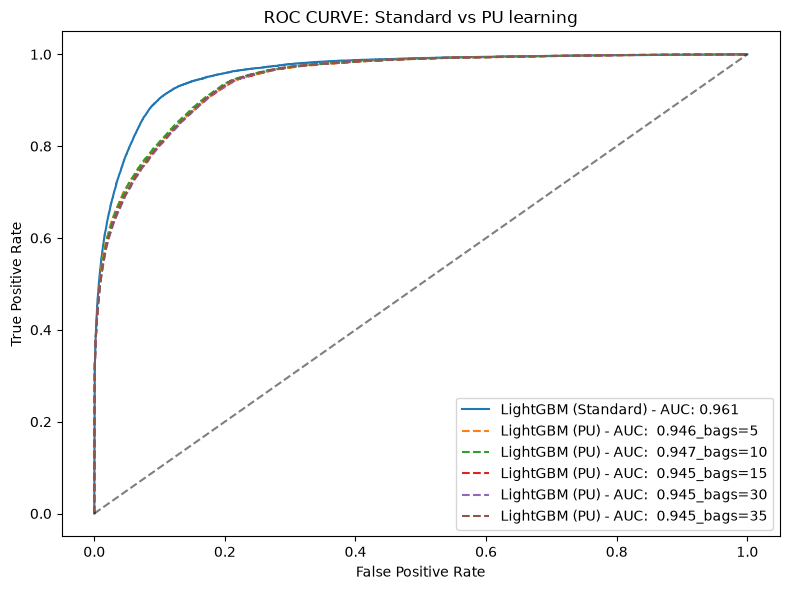

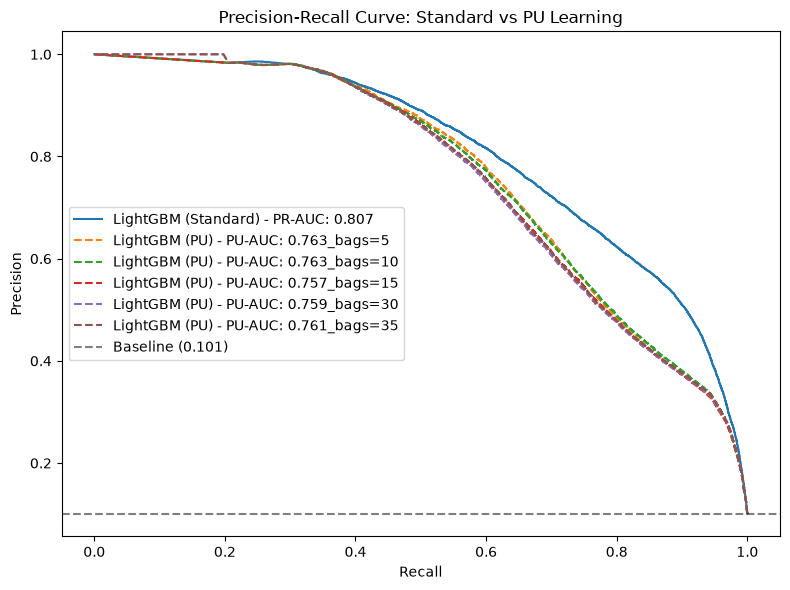

   Model        Type  Threshold  Bag  ROC-AUC  PR-AUC  Precision  Recall  F1-Score
LightGBM    Standard       0.50    0   0.9612  0.8065     0.9026  0.4792    0.6261
LightGBM    Standard       0.51    0   0.9612  0.8065     0.9055  0.4750    0.6231
LightGBM    Standard       0.52    0   0.9612  0.8065     0.9088  0.4709    0.6204
LightGBM    Standard       0.53    0   0.9612  0.8065     0.9111  0.4667    0.6173
LightGBM    Standard       0.54    0   0.9612  0.8065     0.9135  0.4630    0.6145
LightGBM    Standard       0.55    0   0.9612  0.8065     0.9158  0.4587    0.6113
LightGBM    Standard       0.56    0   0.9612  0.8065     0.9173  0.4550    0.6083
LightGBM    Standard       0.57    0   0.9612  0.8065     0.9194  0.4511    0.6053
LightGBM    Standard       0.58    0   0.9612  0.8065     0.9220  0.4465    0.6016
LightGBM    Standard       0.59    0   0.9612  0.8065     0.9235  0.4422    0.5980
LightGBM    Standard       0.60    0   0.9612  0.8065     0.9255  0.4376    0.5942
Ligh

In [16]:
#=================
n_bags=0

base_models = {
    #"Random Forest":RandomForestClassifier(random_state=42),
    #"XGBoost":xgb.XGBClassifier(random_state=42),
    "LightGBM":lgb.LGBMClassifier( learning_rate= 0.05, 
        max_depth= 10,    n_estimators= 200, random_state = 42)
} 

threshold = 0.85
results =[]
#fig_cm, axes_cm = plt.subplots(2, 3, figsize=(15, 9))
fig_roc, ax_roc = plt.subplots(figsize=(8,6))
fig_prc, ax_prc = plt.subplots(figsize=(8,6)) # calculate PR-AUC / AP
best_fitted_models = {}
best_params_dict = {}
best_score_dict = {}
threshold_list= np.arange(0.5, 0.951, 0.01)
for idx, (name, base_clf) in enumerate(base_models.items()):

    best_std_clf = clone(base_clf)
   # best_std_clf.set_params(**best_params)
    best_std_clf.fit(X_train_final, y_train)

    best_fitted_models[name] = best_std_clf
    y_prob_std= best_std_clf.predict_proba(X_test_final)[:, 1]

    for threshold in threshold_list:
        y_pred_std = (y_prob_std >= threshold).astype(int)

        auc_std = roc_auc_score(y_test, y_prob_std)
        pr_auc_std = average_precision_score(y_test, y_prob_std)


        results.append({
            "Model":name, "Type":"Standard", "Threshold":threshold,"Bag":n_bags,
            "ROC-AUC": round(auc_std, 4),
            "PR-AUC": round(pr_auc_std, 4),
            "Precision": round(precision_score(y_test, y_pred_std, zero_division=0), 4),
            "Recall": round(recall_score(y_test, y_pred_std, zero_division=0), 4),
            "F1-Score": round(f1_score(y_test, y_pred_std, zero_division=0), 4)
        })
    prec_std, rec_std, _ = precision_recall_curve(y_test, y_prob_std)
    ax_prc.plot(rec_std, prec_std, label=f'{name} (Standard) - PR-AUC: {pr_auc_std:.3f}')

    fpr_std, tpr_std, _ = roc_curve(y_test, y_prob_std)
    ax_roc.plot(fpr_std, tpr_std, label=f"{name} (Standard) - AUC: {auc_std:.3f}")

        #cm = confusion_matrix(y_test, y_pred_std)
        #sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes_cm[0, idx], cbar=False, xticklabels=['Pred:0','Pred:1'], yticklabels=['True:0', 'True:1'])

        #axes_cm[0, idx].set_title(f"{name} (Standard)")
        #axes_cm[0, idx].set_xlabel(f"Predicted Label")
        #axes_cm[0, idx].set_ylabel(f"True Label")

    #============= Pu model
    bag_list = [5, 10, 15, 30, 35]
    for n_bags in bag_list:
        pu_clf= bagging_rf(n_bags,clone(best_std_clf), X_train_final, y_train)
        y_prob_pu = predict_proba_pu(pu_clf, X_test_final)
        for threshold in threshold_list:
            y_pred_pu = (y_prob_pu >= threshold).astype(int)

            auc_pu = roc_auc_score(y_test, y_prob_pu)
            pr_auc_pu = average_precision_score(y_test, y_prob_pu)
            
            results.append({
                "Model": name, "Type": "PU Learning", "Threshold":threshold,"Bag":n_bags,
                "ROC-AUC": round(auc_pu, 4),
                "PR-AUC":round (pr_auc_pu, 4),
                "Precision": round(precision_score(y_test, y_pred_pu, zero_division=0), 4),
                "Recall": round(recall_score(y_test, y_pred_pu, zero_division=0), 4),
                "F1-Score": round(f1_score(y_test, y_pred_pu, zero_division=0 ), 4)
            })

        fpr_pu, tpr_pu, _ = roc_curve(y_test, y_prob_pu)
        ax_roc.plot(fpr_pu, tpr_pu, linestyle='--', label=f'{name} (PU) - AUC: {auc_pu: .3f}_bags={n_bags}')

        prec_pu, rec_pu, _ = precision_recall_curve(y_test, y_prob_pu)
        ax_prc.plot(rec_pu, prec_pu, linestyle='--', label=f'{name} (PU) - PU-AUC:{pr_auc_pu: .3f}_bags={n_bags}')

    #cm = confusion_matrix(y_test, y_pred_pu)
    #sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes_cm[1, idx], cbar=False, xticklabels=['Pred:0','Pred:1'], yticklabels=['True:0', 'True:1'])
    #xes_cm[1, idx].set_title(f"{name} (PU)")
    #axes_cm[1, idx].set_xlabel("Predicted Label")
    #axes_cm[1, idx].set_ylabel("True Label")

ax_roc.plot([0, 1], [0,1], 'k--', alpha=0.5)
ax_roc.set_title("ROC CURVE: Standard vs PU learning")
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.legend()

fig_roc.tight_layout()
fig_roc.savefig("img/PU_ROC_Comparison_lightgb_bag_compar.png")



baseline_pr = np.sum(y_test == 1) / len(y_test)
ax_prc.axhline(y=baseline_pr, color='k', linestyle='--', alpha=0.5, label=f'Baseline ({baseline_pr:.3f})')
ax_prc.set_title("Precision-Recall Curve: Standard vs PU Learning")
ax_prc.set_xlabel("Recall")
ax_prc.set_ylabel("Precision")
ax_prc.legend()
fig_prc.tight_layout()
fig_prc.savefig("img/PU_PRC_Comparison_lightgbm_bag_compar.png")


#fig_cm.tight_layout()
#fig_cm.savefig("img/PU_Confusion_Matrix_Comparison_XGBOOST_bag_compar.png")


plt.show()


df_metrics = pd.DataFrame(results)
print(df_metrics.to_string(index=False))
df_metrics.to_csv("img/PU_vs_Standard_Metrics_lightgb_bag_compar.csv", index=False)
#===========Rf model 

### again, with best parameter, three model comparison
best para:
rf: 'max_depth': 20, 'n_estimators': 100
xgb:'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 300
lightgbn:'learning_rate': 0.05, 'max_depth': 10, 'n_estimators': 200

In [17]:

tsfe = TSFE(feature_cols=feature_cols, feature_config=feature_config)
X_train_final = tsfe.transform(X_train)

X_test_final = tsfe.transform(X_test)
X_train_final.columns.tolist()

['type',
 'pflow',
 'tmod',
 'CH4_rt',
 'CH4_w',
 'CH4_ht',
 'CH4_area',
 'CH4_skew',
 'CH4_start_time',
 'CH4_end_time',
 'CH4_start_level',
 'CH4_end_level',
 'is_air',
 'is_std',
 'last_std_CH4_ht',
 'last_air_CH4_ht',
 'last_std_CH4_area',
 'last_air_CH4_area',
 'last_std_CH4_rt',
 'last_air_CH4_rt',
 'last_std_CH4_start_level',
 'last_air_CH4_start_level',
 'CH4_ht_to_last_std_ratio',
 'CH4_ht_to_last_air_ratio',
 'CH4_area_to_last_std_ratio',
 'CH4_area_to_last_air_ratio',
 'CH4_rt_to_last_std_ratio',
 'CH4_rt_to_last_air_ratio',
 'CH4_start_level_to_last_std_ratio',
 'CH4_start_level_to_last_air_ratio',
 'duration_rt_ratio',
 'rt_position',
 'baseline_slope',
 'level_area_ratio',
 'CH4_area_diff_1',
 'CH4_area_diff_3',
 'CH4_area_diff_6',
 'CH4_area_diff_72',
 'CH4_ht_diff_1',
 'CH4_ht_diff_3',
 'CH4_ht_diff_6',
 'CH4_ht_diff_72',
 'CH4_w_diff_1',
 'CH4_w_diff_3',
 'CH4_w_diff_6',
 'CH4_w_diff_72',
 'CH4_rt_diff_1',
 'CH4_rt_diff_3',
 'CH4_rt_diff_6',
 'CH4_rt_diff_72',
 'CH4_ar

In [18]:
X_train_final, X_test_final = (X_train_final.drop(columns='type'), 
                               X_test_final.drop(columns='type'))

Number of Bag: 5
Positive: 21442
Unlabeled: 600338

 PU training data, Bag 1/5 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 2/5 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 3/5 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 4/5 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 5/5 Positive = 21442, Unlabeled = 21442
Number of Bag: 10
Positive: 21442
Unlabeled: 600338

 PU training data, Bag 1/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 2/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 3/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 4/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 5/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 6/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 7/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 8/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 9/10 Positive = 21442, Unlabeled 

/tmp/ipykernel_2028/2638823168.py:105: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig_prc.tight_layout()
/tmp/ipykernel_2028/2638823168.py:106: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig_prc.savefig("img/PU_PRC_Comparison_lightgbm_bag_compar.png")


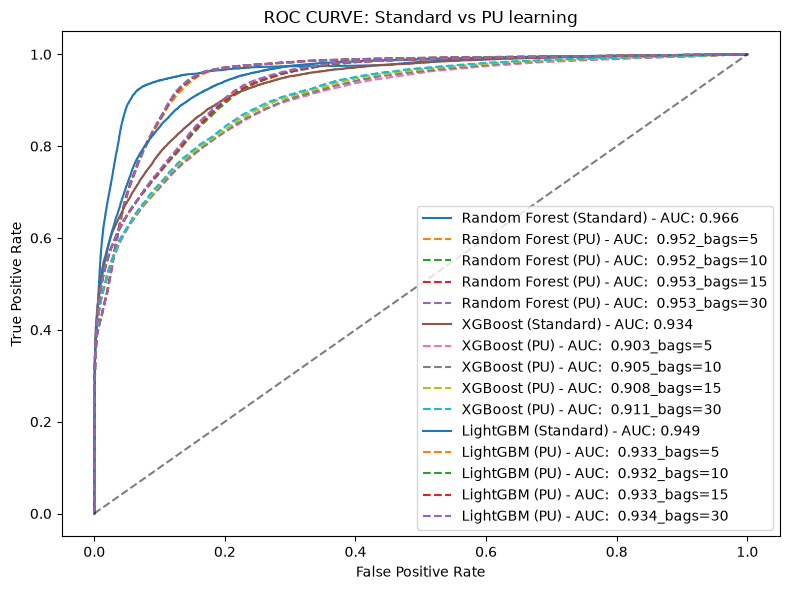

/home/ellie/research_project/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


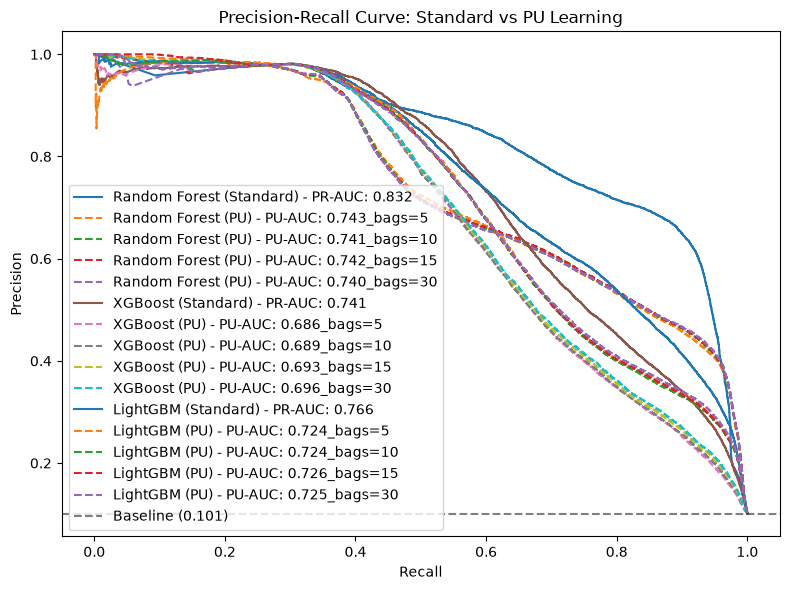

        Model        Type  Threshold  Bag  ROC-AUC  PR-AUC  Precision  Recall  F1-Score
Random Forest    Standard       0.50    0   0.9659  0.8318     0.9161  0.4265    0.5820
Random Forest    Standard       0.51    0   0.9659  0.8318     0.9186  0.4219    0.5782
Random Forest    Standard       0.52    0   0.9659  0.8318     0.9207  0.4166    0.5736
Random Forest    Standard       0.53    0   0.9659  0.8318     0.9235  0.4103    0.5682
Random Forest    Standard       0.54    0   0.9659  0.8318     0.9267  0.4053    0.5640
Random Forest    Standard       0.55    0   0.9659  0.8318     0.9288  0.4005    0.5597
Random Forest    Standard       0.56    0   0.9659  0.8318     0.9311  0.3960    0.5556
Random Forest    Standard       0.57    0   0.9659  0.8318     0.9344  0.3909    0.5512
Random Forest    Standard       0.58    0   0.9659  0.8318     0.9363  0.3879    0.5486
Random Forest    Standard       0.59    0   0.9659  0.8318     0.9386  0.3842    0.5452
Random Forest    Standard       

In [19]:

#=================
n_bags=0

base_models = {
    "Random Forest":RandomForestClassifier(max_depth= 20, n_estimators=100, random_state=42),
    "XGBoost":xgb.XGBClassifier(learning_rate=0.1, max_depth=6, n_estimators=300,random_state=42),
    "LightGBM":lgb.LGBMClassifier( learning_rate= 0.05, max_depth= 10,  n_estimators= 200, random_state = 42)
} 

threshold = 0.80
results =[]
#fig_cm, axes_cm = plt.subplots(2, 3, figsize=(15, 9))
fig_roc, ax_roc = plt.subplots(figsize=(8,6))
fig_prc, ax_prc = plt.subplots(figsize=(8,6)) # calculate PR-AUC / AP
best_fitted_models = {}
best_params_dict = {}
best_score_dict = {}
threshold_list= np.arange(0.5, 0.951, 0.01)
for idx, (name, base_clf) in enumerate(base_models.items()):

    best_std_clf = clone(base_clf)
   # best_std_clf.set_params(**best_params)
    best_std_clf.fit(X_train_final, y_train)

    best_fitted_models[name] = best_std_clf
    y_prob_std= best_std_clf.predict_proba(X_test_final)[:, 1]

    for threshold in threshold_list:
        y_pred_std = (y_prob_std >= threshold).astype(int)

        auc_std = roc_auc_score(y_test, y_prob_std)
        pr_auc_std = average_precision_score(y_test, y_prob_std)


        results.append({
            "Model":name, "Type":"Standard", "Threshold":threshold,"Bag":n_bags,
            "ROC-AUC": round(auc_std, 4),
            "PR-AUC": round(pr_auc_std, 4),
            "Precision": round(precision_score(y_test, y_pred_std, zero_division=0), 4),
            "Recall": round(recall_score(y_test, y_pred_std, zero_division=0), 4),
            "F1-Score": round(f1_score(y_test, y_pred_std, zero_division=0), 4)
        })
    prec_std, rec_std, _ = precision_recall_curve(y_test, y_prob_std)
    ax_prc.plot(rec_std, prec_std, label=f'{name} (Standard) - PR-AUC: {pr_auc_std:.3f}')

    fpr_std, tpr_std, _ = roc_curve(y_test, y_prob_std)
    ax_roc.plot(fpr_std, tpr_std, label=f"{name} (Standard) - AUC: {auc_std:.3f}")

        #cm = confusion_matrix(y_test, y_pred_std)
        #sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes_cm[0, idx], cbar=False, xticklabels=['Pred:0','Pred:1'], yticklabels=['True:0', 'True:1'])

        #axes_cm[0, idx].set_title(f"{name} (Standard)")
        #axes_cm[0, idx].set_xlabel(f"Predicted Label")
        #axes_cm[0, idx].set_ylabel(f"True Label")

    #============= Pu model
    bag_list = [5, 10, 15, 30]
    for n_bags in bag_list:
        pu_clf= bagging_rf(n_bags,clone(best_std_clf), X_train_final, y_train)
        y_prob_pu = predict_proba_pu(pu_clf, X_test_final)
        for threshold in threshold_list:
            y_pred_pu = (y_prob_pu >= threshold).astype(int)

            auc_pu = roc_auc_score(y_test, y_prob_pu)
            pr_auc_pu = average_precision_score(y_test, y_prob_pu)
            
            results.append({
                "Model": name, "Type": "PU Learning", "Threshold":threshold,"Bag":n_bags,
                "ROC-AUC": round(auc_pu, 4),
                "PR-AUC":round (pr_auc_pu, 4),
                "Precision": round(precision_score(y_test, y_pred_pu, zero_division=0), 4),
                "Recall": round(recall_score(y_test, y_pred_pu, zero_division=0), 4),
                "F1-Score": round(f1_score(y_test, y_pred_pu, zero_division=0 ), 4)
            })

        fpr_pu, tpr_pu, _ = roc_curve(y_test, y_prob_pu)
        ax_roc.plot(fpr_pu, tpr_pu, linestyle='--', label=f'{name} (PU) - AUC: {auc_pu: .3f}_bags={n_bags}')

        prec_pu, rec_pu, _ = precision_recall_curve(y_test, y_prob_pu)
        ax_prc.plot(rec_pu, prec_pu, linestyle='--', label=f'{name} (PU) - PU-AUC:{pr_auc_pu: .3f}_bags={n_bags}')

    #cm = confusion_matrix(y_test, y_pred_pu)
    #sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes_cm[1, idx], cbar=False, xticklabels=['Pred:0','Pred:1'], yticklabels=['True:0', 'True:1'])
    #xes_cm[1, idx].set_title(f"{name} (PU)")
    #axes_cm[1, idx].set_xlabel("Predicted Label")
    #axes_cm[1, idx].set_ylabel("True Label")

ax_roc.plot([0, 1], [0,1], 'k--', alpha=0.5)
ax_roc.set_title("ROC CURVE: Standard vs PU learning")
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.legend()

fig_roc.tight_layout()
fig_roc.savefig("img/PU_ROC_Comparison_lightgb_bag_compar.png")



baseline_pr = np.sum(y_test == 1) / len(y_test)
ax_prc.axhline(y=baseline_pr, color='k', linestyle='--', alpha=0.5, label=f'Baseline ({baseline_pr:.3f})')
ax_prc.set_title("Precision-Recall Curve: Standard vs PU Learning")
ax_prc.set_xlabel("Recall")
ax_prc.set_ylabel("Precision")
ax_prc.legend()
fig_prc.tight_layout()
fig_prc.savefig("img/PU_PRC_Comparison_lightgbm_bag_compar.png")


#fig_cm.tight_layout()
#fig_cm.savefig("img/PU_Confusion_Matrix_Comparison_XGBOOST_bag_compar.png")


plt.show()


df_metrics = pd.DataFrame(results)
print(df_metrics.to_string(index=False))
df_metrics.to_csv("img/PU_vs_Standard_Metrics_lightgb_bag_compar.csv", index=False)
#===========Rf model 

# 30 bags with confusion matrix
# best parameter

Number of Bag: 30
Positive: 21442
Unlabeled: 600338

 PU training data, Bag 1/30 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 2/30 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 3/30 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 4/30 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 5/30 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 6/30 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 7/30 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 8/30 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 9/30 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 10/30 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 11/30 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 12/30 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 13/30 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 14/30 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 15/30 Pos

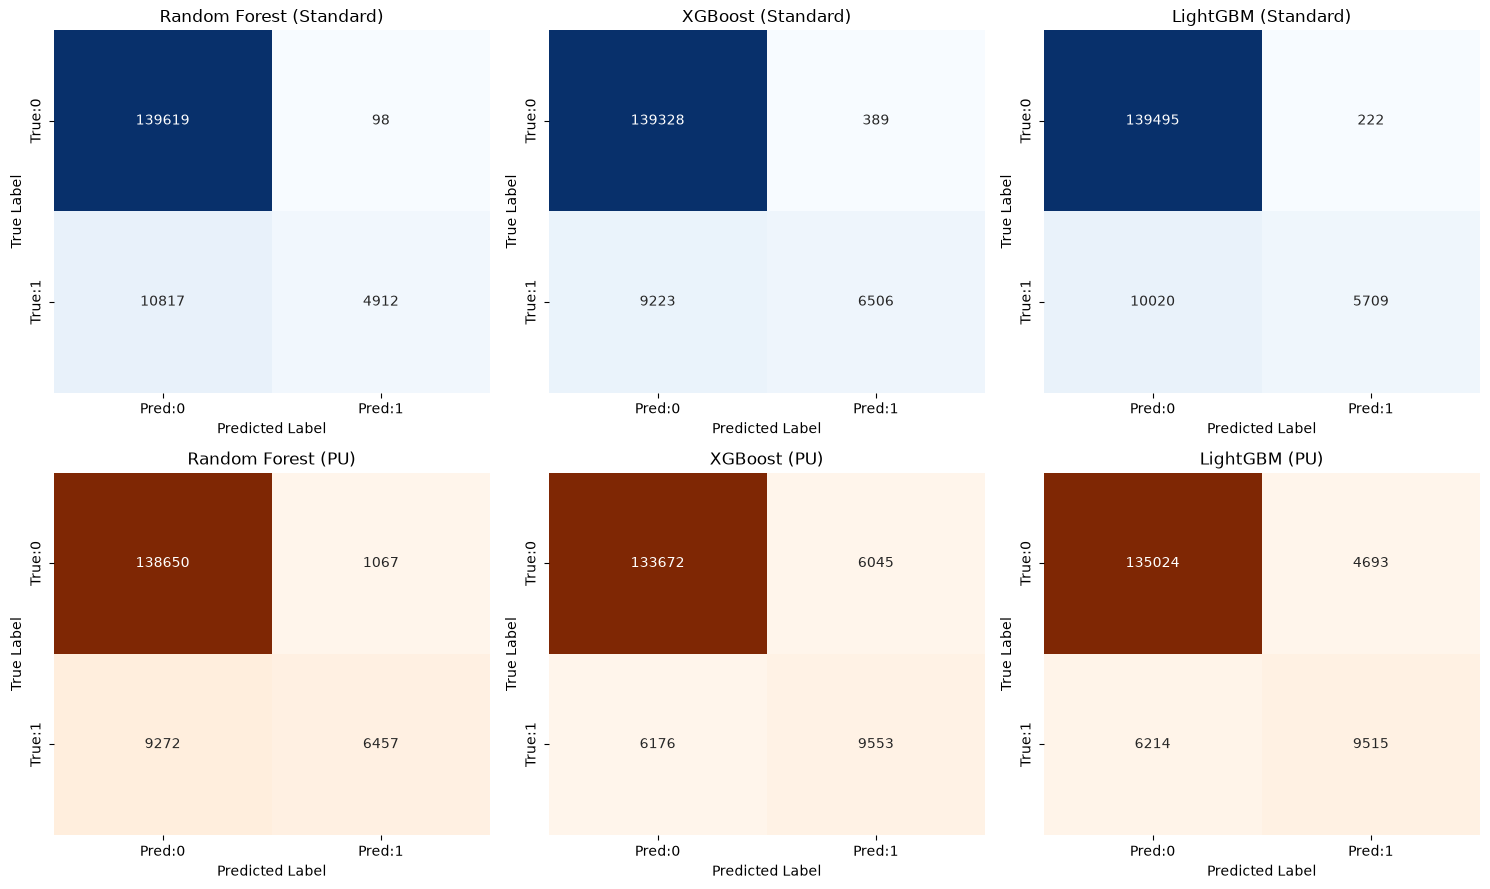

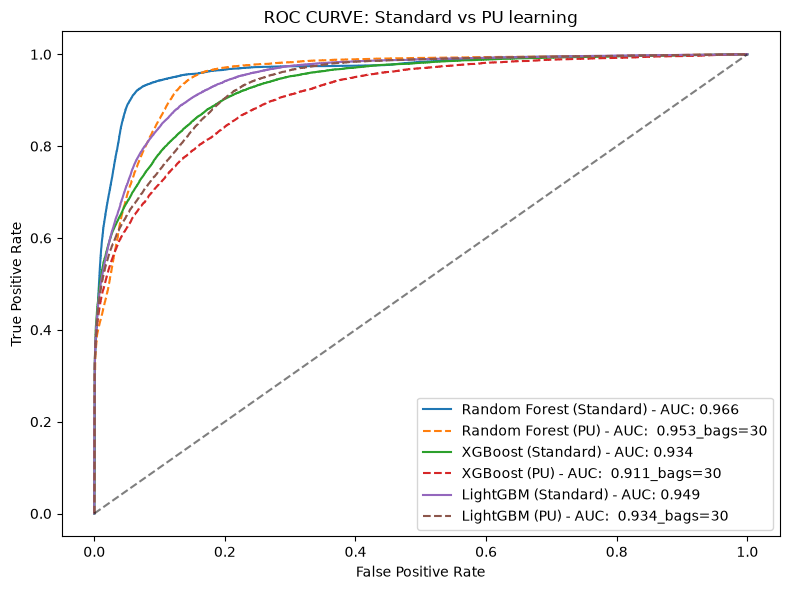

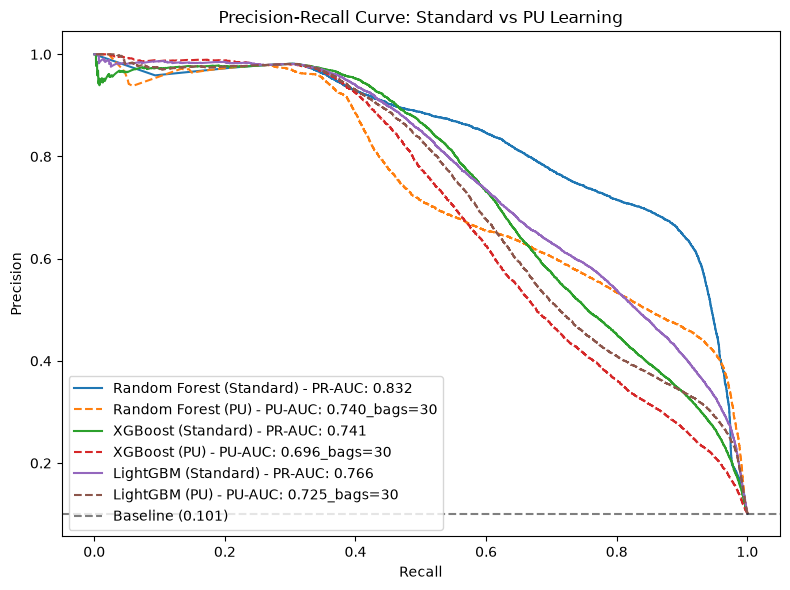

        Model        Type  Threshold  ROC-AUC  PR-AUC  Precision  Recall  F1-Score
Random Forest    Standard        0.8   0.9659  0.8318     0.9804  0.3123    0.4737
Random Forest PU Learning        0.8   0.9526  0.7404     0.8582  0.4105    0.5554
      XGBoost    Standard        0.8   0.9342  0.7411     0.9436  0.4136    0.5751
      XGBoost PU Learning        0.8   0.9106  0.6959     0.6125  0.6073    0.6099
     LightGBM    Standard        0.8   0.9492  0.7659     0.9626  0.3630    0.5271
     LightGBM PU Learning        0.8   0.9339  0.7248     0.6697  0.6049    0.6357


In [20]:

#=================

base_models = {
    "Random Forest":RandomForestClassifier(max_depth= 20, n_estimators=100, random_state=42),
    "XGBoost":xgb.XGBClassifier(learning_rate=0.1, max_depth=6, n_estimators=300,random_state=42),
    "LightGBM":lgb.LGBMClassifier( learning_rate= 0.05, max_depth= 10,  n_estimators= 200, random_state = 42)
} 
threshold = 0.8
results =[]
fig_cm, axes_cm = plt.subplots(2, 3, figsize=(15, 9))
fig_roc, ax_roc = plt.subplots(figsize=(8,6))
fig_prc, ax_prc = plt.subplots(figsize=(8,6)) # 計算 PR-AUC / AP


for idx, (name, base_clf) in enumerate(base_models.items()):
    std_clf = clone(base_clf)
    std_clf.fit(X_train_final, y_train)

    y_prob_std= std_clf.predict_proba(X_test_final)[:, 1]
    y_pred_std = (y_prob_std >= threshold).astype(int)

    auc_std = roc_auc_score(y_test, y_prob_std)
    pr_auc_std = average_precision_score(y_test, y_prob_std)

    prec_std, rec_std, _ = precision_recall_curve(y_test, y_prob_std)
    ax_prc.plot(rec_std, prec_std, label=f'{name} (Standard) - PR-AUC: {pr_auc_std:.3f}')
    

    results.append({
        "Model":name, "Type":"Standard", "Threshold":threshold,
        "ROC-AUC": round(auc_std, 4),
        "PR-AUC": round(pr_auc_std, 4),
        "Precision": round(precision_score(y_test, y_pred_std, zero_division=0), 4),
        "Recall": round(recall_score(y_test, y_pred_std, zero_division=0), 4),
        "F1-Score": round(f1_score(y_test, y_pred_std, zero_division=0), 4)
    })

    fpr_std, tpr_std, _ = roc_curve(y_test, y_prob_std)
    ax_roc.plot(fpr_std, tpr_std, label=f"{name} (Standard) - AUC: {auc_std:.3f}")

    cm = confusion_matrix(y_test, y_pred_std)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes_cm[0, idx], cbar=False, xticklabels=['Pred:0','Pred:1'], yticklabels=['True:0', 'True:1'])

    axes_cm[0, idx].set_title(f"{name} (Standard)")
    axes_cm[0, idx].set_xlabel(f"Predicted Label")
    axes_cm[0, idx].set_ylabel(f"True Label")

    #============= Pu model
    n_bags= 30
    pu_clf= bagging_rf(n_bags,clone(base_clf), X_train_final, y_train)

    y_prob_pu = predict_proba_pu(pu_clf, X_test_final)
    y_pred_pu = (y_prob_pu >= threshold).astype(int)

    auc_pu = roc_auc_score(y_test, y_prob_pu)
    pr_auc_pu = average_precision_score(y_test, y_prob_pu)
    
    results.append({
        "Model": name, "Type": "PU Learning", "Threshold":threshold,
        "ROC-AUC": round(auc_pu, 4),
        "PR-AUC":round (pr_auc_pu, 4),
        "Precision": round(precision_score(y_test, y_pred_pu, zero_division=0), 4),
        "Recall": round(recall_score(y_test, y_pred_pu, zero_division=0), 4),
        "F1-Score": round(f1_score(y_test, y_pred_pu, zero_division=0 ), 4)
    })

    fpr_pu, tpr_pu, _ = roc_curve(y_test, y_prob_pu)
    ax_roc.plot(fpr_pu, tpr_pu, linestyle='--', label=f'{name} (PU) - AUC: {auc_pu: .3f}_bags={n_bags}')

    prec_pu, rec_pu, _ = precision_recall_curve(y_test, y_prob_pu)
    ax_prc.plot(rec_pu, prec_pu, linestyle='--', label=f'{name} (PU) - PU-AUC:{pr_auc_pu: .3f}_bags={n_bags}')

    cm = confusion_matrix(y_test, y_pred_pu)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes_cm[1, idx], cbar=False, xticklabels=['Pred:0','Pred:1'], yticklabels=['True:0', 'True:1'])
    axes_cm[1, idx].set_title(f"{name} (PU)")
    axes_cm[1, idx].set_xlabel("Predicted Label")
    axes_cm[1, idx].set_ylabel("True Label")

ax_roc.plot([0, 1], [0,1], 'k--', alpha=0.5)
ax_roc.set_title("ROC CURVE: Standard vs PU learning")
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.legend()

fig_roc.tight_layout()
fig_roc.savefig("img/PU_ROC_Comparison_30bags_final.png")



baseline_pr = np.sum(y_test == 1) / len(y_test)
ax_prc.axhline(y=baseline_pr, color='k', linestyle='--', alpha=0.5, label=f'Baseline ({baseline_pr:.3f})')
ax_prc.set_title("Precision-Recall Curve: Standard vs PU Learning")
ax_prc.set_xlabel("Recall")
ax_prc.set_ylabel("Precision")
ax_prc.legend()
fig_prc.tight_layout()
fig_prc.savefig("img/PU_PRC_Comparison_30bags_final.png")


fig_cm.tight_layout()
fig_cm.savefig("img/PU_Confusion_Matrix_Comparison_30bags_final.png")


plt.show()


df_metrics = pd.DataFrame(results)
print(df_metrics.to_string(index=False))
df_metrics.to_csv("img/PU_vs_Standard_Metrics_30bags_final.csv", index=False)
#===========

=====> top 30 feature is enough 

what if we use the features that selected from rf model?

In [21]:
feature_ml = ['level_area_ratio',
 'CH4_ht_to_last_std_ratio',
 'CH4_area_mad_3h',
 'CH4_ht_roll_std_1h',
 'CH4_w_roll_std_3h_CH4_w_roll_mean_3h_ratio',
 'CH4_ht',
 'CH4_skew',
 'CH4_area_to_last_std_ratio',
 'CH4_ht_roll_mean_1h',
 'CH4_area_roll_std_1h',
 'CH4_ht_pflow_ratio',
 'CH4_ht_mad_3h',
 'CH4_w_residual_3h',
 'CH4_w_residual_1h',
 'CH4_w_diff_1',
 'CH4_rt_to_last_std_ratio',
 'CH4_w_roll_std_1h',
 'CH4_area_pflow_ratio',
 'CH4_w_robust_residual_1h',
 'CH4_ht_roll_median_1h',
 'CH4_rt_to_last_air_ratio',
 'last_std_CH4_ht',
 'CH4_w_robust_residual_6h',
 'CH4_w_roll_mean_1h',
 'CH4_w_residual_6h',
 'CH4_w_roll_median_1h',
 'CH4_area_roll_mean_1h',
 'CH4_ht_roll_std_3h_CH4_ht_roll_mean_3h_ratio',
 'CH4_w_roll_std_3h',
 'CH4_rt_roll_mean_1h',]

In [22]:
X_train_final  = X_train_final [feature_ml]
X_test_final  = X_test_final [feature_ml]

Number of Bag: 5
Positive: 21442
Unlabeled: 600338

 PU training data, Bag 1/5 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 2/5 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 3/5 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 4/5 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 5/5 Positive = 21442, Unlabeled = 21442
Number of Bag: 10
Positive: 21442
Unlabeled: 600338

 PU training data, Bag 1/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 2/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 3/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 4/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 5/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 6/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 7/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 8/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 9/10 Positive = 21442, Unlabeled 

/tmp/ipykernel_2028/1470908511.py:105: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig_prc.tight_layout()
/tmp/ipykernel_2028/1470908511.py:106: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig_prc.savefig("img/PU_PRC_Comparison_lightgbm_bag_compar_rffeature.png")


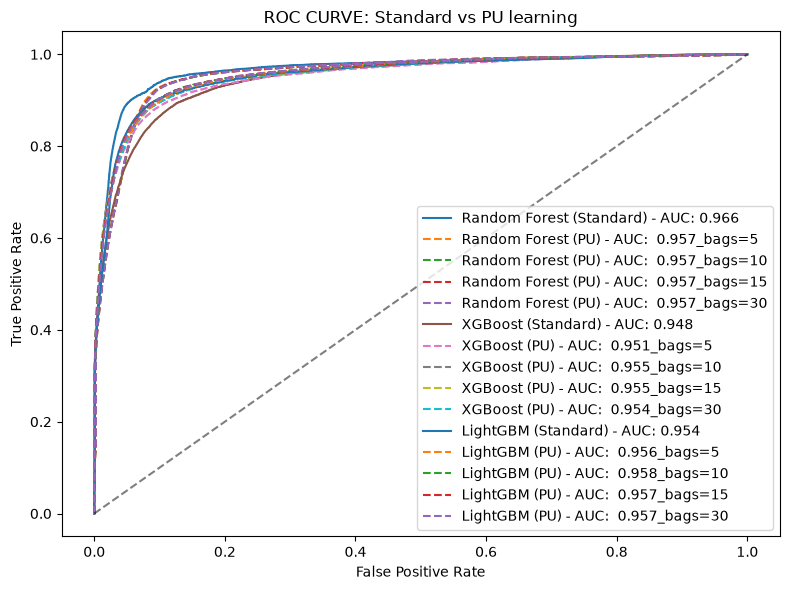

/home/ellie/research_project/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


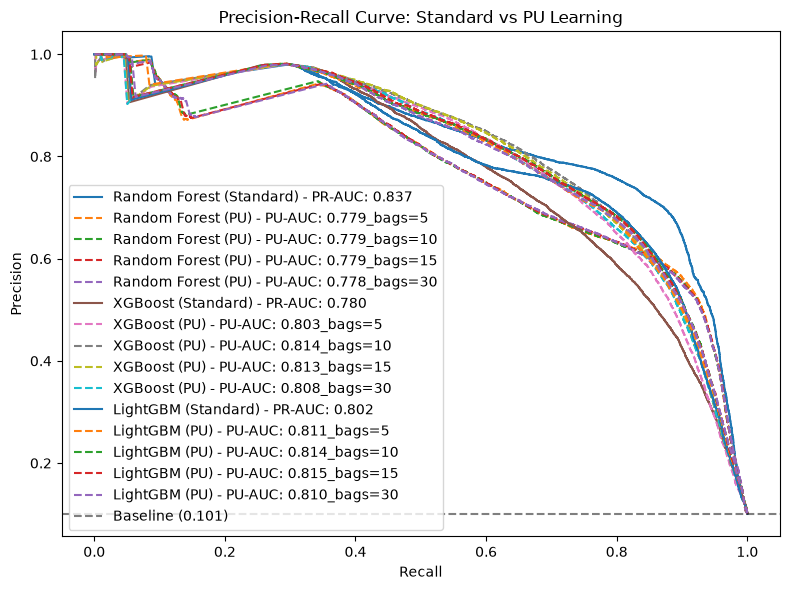

        Model        Type  Threshold  Bag  ROC-AUC  PR-AUC  Precision  Recall  F1-Score
Random Forest    Standard       0.50    0   0.9662  0.8373     0.8958  0.4549    0.6034
Random Forest    Standard       0.51    0   0.9662  0.8373     0.8991  0.4483    0.5983
Random Forest    Standard       0.52    0   0.9662  0.8373     0.9018  0.4412    0.5925
Random Forest    Standard       0.53    0   0.9662  0.8373     0.9039  0.4342    0.5866
Random Forest    Standard       0.54    0   0.9662  0.8373     0.9079  0.4293    0.5829
Random Forest    Standard       0.55    0   0.9662  0.8373     0.9118  0.4233    0.5782
Random Forest    Standard       0.56    0   0.9662  0.8373     0.9143  0.4179    0.5736
Random Forest    Standard       0.57    0   0.9662  0.8373     0.9177  0.4095    0.5663
Random Forest    Standard       0.58    0   0.9662  0.8373     0.9215  0.4047    0.5624
Random Forest    Standard       0.59    0   0.9662  0.8373     0.9244  0.3993    0.5577
Random Forest    Standard       

In [23]:

#=================
n_bags=0

base_models = {
    "Random Forest":RandomForestClassifier(max_depth= 20, n_estimators=100, random_state=42),
    "XGBoost":xgb.XGBClassifier(learning_rate=0.1, max_depth=6, n_estimators=300,random_state=42),
    "LightGBM":lgb.LGBMClassifier( learning_rate= 0.05, max_depth= 10,  n_estimators= 200, random_state = 42)
} 

threshold = 0.80
results =[]
#fig_cm, axes_cm = plt.subplots(2, 3, figsize=(15, 9))
fig_roc, ax_roc = plt.subplots(figsize=(8,6))
fig_prc, ax_prc = plt.subplots(figsize=(8,6)) # calculate PR-AUC / AP
best_fitted_models = {}
best_params_dict = {}
best_score_dict = {}
threshold_list= np.arange(0.5, 0.951, 0.01)
for idx, (name, base_clf) in enumerate(base_models.items()):

    best_std_clf = clone(base_clf)
   # best_std_clf.set_params(**best_params)
    best_std_clf.fit(X_train_final, y_train)

    best_fitted_models[name] = best_std_clf
    y_prob_std= best_std_clf.predict_proba(X_test_final)[:, 1]

    for threshold in threshold_list:
        y_pred_std = (y_prob_std >= threshold).astype(int)

        auc_std = roc_auc_score(y_test, y_prob_std)
        pr_auc_std = average_precision_score(y_test, y_prob_std)


        results.append({
            "Model":name, "Type":"Standard", "Threshold":threshold,"Bag":n_bags,
            "ROC-AUC": round(auc_std, 4),
            "PR-AUC": round(pr_auc_std, 4),
            "Precision": round(precision_score(y_test, y_pred_std, zero_division=0), 4),
            "Recall": round(recall_score(y_test, y_pred_std, zero_division=0), 4),
            "F1-Score": round(f1_score(y_test, y_pred_std, zero_division=0), 4)
        })
    prec_std, rec_std, _ = precision_recall_curve(y_test, y_prob_std)
    ax_prc.plot(rec_std, prec_std, label=f'{name} (Standard) - PR-AUC: {pr_auc_std:.3f}')

    fpr_std, tpr_std, _ = roc_curve(y_test, y_prob_std)
    ax_roc.plot(fpr_std, tpr_std, label=f"{name} (Standard) - AUC: {auc_std:.3f}")

        #cm = confusion_matrix(y_test, y_pred_std)
        #sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes_cm[0, idx], cbar=False, xticklabels=['Pred:0','Pred:1'], yticklabels=['True:0', 'True:1'])

        #axes_cm[0, idx].set_title(f"{name} (Standard)")
        #axes_cm[0, idx].set_xlabel(f"Predicted Label")
        #axes_cm[0, idx].set_ylabel(f"True Label")

    #============= Pu model
    bag_list = [5, 10, 15, 30]
    for n_bags in bag_list:
        pu_clf= bagging_rf(n_bags,clone(best_std_clf), X_train_final, y_train)
        y_prob_pu = predict_proba_pu(pu_clf, X_test_final)
        for threshold in threshold_list:
            y_pred_pu = (y_prob_pu >= threshold).astype(int)

            auc_pu = roc_auc_score(y_test, y_prob_pu)
            pr_auc_pu = average_precision_score(y_test, y_prob_pu)
            
            results.append({
                "Model": name, "Type": "PU Learning", "Threshold":threshold,"Bag":n_bags,
                "ROC-AUC": round(auc_pu, 4),
                "PR-AUC":round (pr_auc_pu, 4),
                "Precision": round(precision_score(y_test, y_pred_pu, zero_division=0), 4),
                "Recall": round(recall_score(y_test, y_pred_pu, zero_division=0), 4),
                "F1-Score": round(f1_score(y_test, y_pred_pu, zero_division=0 ), 4)
            })

        fpr_pu, tpr_pu, _ = roc_curve(y_test, y_prob_pu)
        ax_roc.plot(fpr_pu, tpr_pu, linestyle='--', label=f'{name} (PU) - AUC: {auc_pu: .3f}_bags={n_bags}')

        prec_pu, rec_pu, _ = precision_recall_curve(y_test, y_prob_pu)
        ax_prc.plot(rec_pu, prec_pu, linestyle='--', label=f'{name} (PU) - PU-AUC:{pr_auc_pu: .3f}_bags={n_bags}')

    #cm = confusion_matrix(y_test, y_pred_pu)
    #sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes_cm[1, idx], cbar=False, xticklabels=['Pred:0','Pred:1'], yticklabels=['True:0', 'True:1'])
    #xes_cm[1, idx].set_title(f"{name} (PU)")
    #axes_cm[1, idx].set_xlabel("Predicted Label")
    #axes_cm[1, idx].set_ylabel("True Label")

ax_roc.plot([0, 1], [0,1], 'k--', alpha=0.5)
ax_roc.set_title("ROC CURVE: Standard vs PU learning")
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.legend()

fig_roc.tight_layout()
fig_roc.savefig("img/PU_ROC_Comparison_lightgb_bag_compar_rffeature.png")



baseline_pr = np.sum(y_test == 1) / len(y_test)
ax_prc.axhline(y=baseline_pr, color='k', linestyle='--', alpha=0.5, label=f'Baseline ({baseline_pr:.3f})')
ax_prc.set_title("Precision-Recall Curve: Standard vs PU Learning")
ax_prc.set_xlabel("Recall")
ax_prc.set_ylabel("Precision")
ax_prc.legend()
fig_prc.tight_layout()
fig_prc.savefig("img/PU_PRC_Comparison_lightgbm_bag_compar_rffeature.png")


#fig_cm.tight_layout()
#fig_cm.savefig("img/PU_Confusion_Matrix_Comparison_XGBOOST_bag_compar.png")


plt.show()


df_metrics = pd.DataFrame(results)
print(df_metrics.to_string(index=False))
df_metrics.to_csv("img/PU_vs_Standard_Metrics_lightgb_bag_compar_rffeature.csv", index=False)
#===========Rf model 

==========


oops this one is not right, it's default model

Number of Bag: 5
Positive: 21442
Unlabeled: 600338

 PU training data, Bag 1/5 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 2/5 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 3/5 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 4/5 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 5/5 Positive = 21442, Unlabeled = 21442
Number of Bag: 10
Positive: 21442
Unlabeled: 600338

 PU training data, Bag 1/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 2/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 3/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 4/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 5/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 6/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 7/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 8/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 9/10 Positive = 21442, Unlabeled 

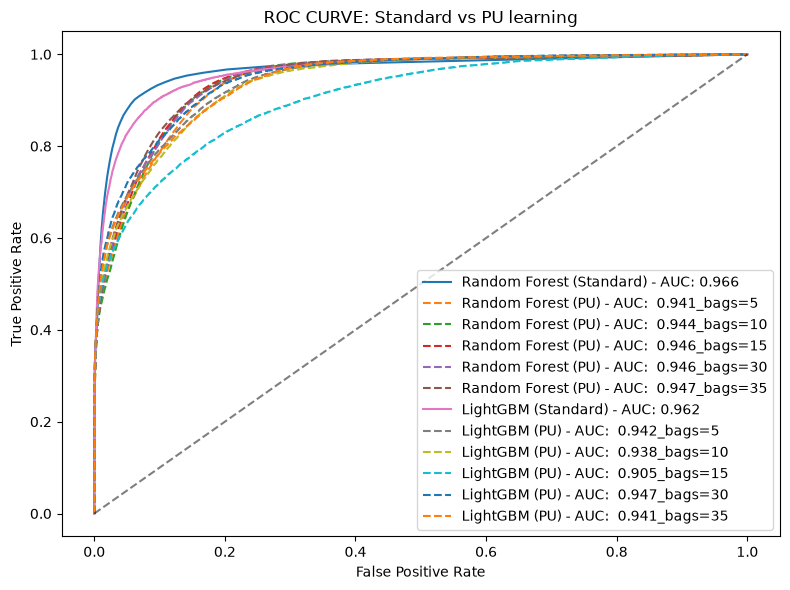

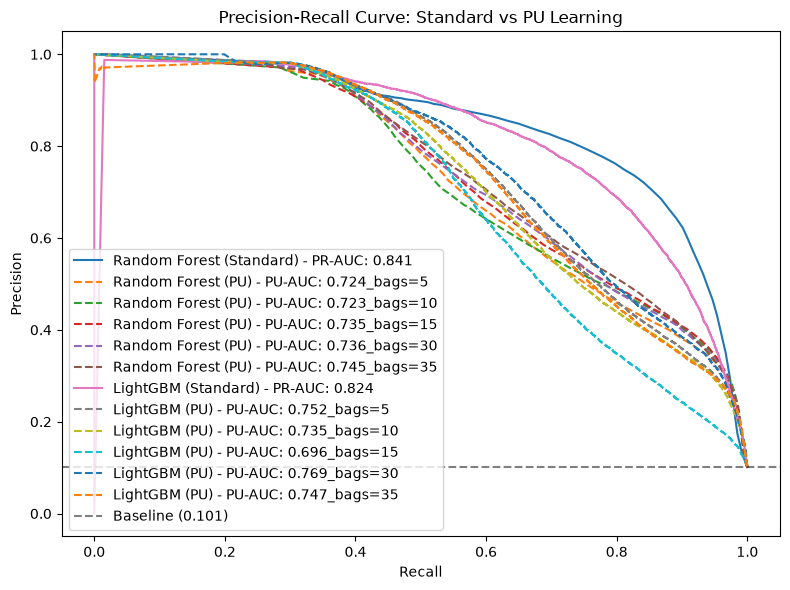

        Model        Type  Threshold  Bag  ROC-AUC  PR-AUC  Precision  Recall  F1-Score
Random Forest    Standard       0.50    0   0.9661  0.8413     0.9115  0.4359    0.5897
Random Forest    Standard       0.51    0   0.9661  0.8413     0.9136  0.4293    0.5841
Random Forest    Standard       0.52    0   0.9661  0.8413     0.9169  0.4235    0.5794
Random Forest    Standard       0.53    0   0.9661  0.8413     0.9195  0.4181    0.5749
Random Forest    Standard       0.54    0   0.9661  0.8413     0.9204  0.4124    0.5696
Random Forest    Standard       0.55    0   0.9661  0.8413     0.9236  0.4094    0.5673
Random Forest    Standard       0.56    0   0.9661  0.8413     0.9247  0.4050    0.5633
Random Forest    Standard       0.57    0   0.9661  0.8413     0.9298  0.3981    0.5575
Random Forest    Standard       0.58    0   0.9661  0.8413     0.9321  0.3951    0.5550
Random Forest    Standard       0.59    0   0.9661  0.8413     0.9344  0.3928    0.5531
Random Forest    Standard       

In [ ]:

#=================
n_bags=0
param_grids = {
    "Random Forest":{
        'n_estimators':[100],
        'max_depth': [10, 20],
        #'min_samples_split':[2, 5],
        #'class_weight':['balanced']
        },
    "XGBoost":{
        'n_estimators':[150, 200, 300],
        'max_depth':[4, 5, 6],
        'learning_rate':[0.1]
       # 'subample':[0.8],
        #'colsample_bytree':[0.8]
        },
    "LightGBM":{
        'learning_rate': 0.05, 
        'max_depth': 10, 
        'n_estimators': 200
        #'verbose':[-1]
    }
}
base_models = {
    "Random Forest":RandomForestClassifier(random_state=42),
    #"XGBoost":xgb.XGBClassifier(random_state=42),
    "LightGBM":lgb.LGBMClassifier(random_state = 42)
} 

threshold = 0.85
results =[]
#fig_cm, axes_cm = plt.subplots(2, 3, figsize=(15, 9))
fig_roc, ax_roc = plt.subplots(figsize=(8,6))
fig_prc, ax_prc = plt.subplots(figsize=(8,6)) # calculate PR-AUC / AP
best_fitted_models = {}
best_params_dict = {}
best_score_dict = {}
threshold_list= np.arange(0.5, 0.951, 0.01)
for idx, (name, base_clf) in enumerate(base_models.items()):


   # base_clf.fit(X_sub, y_sub)

    #best_params= grid_search.best_params_
    #best_params_dict[name] = grid_search.best_params_
    #best_score_dict[name] = grid_search.best_score_
    
    #print(f"Best parameter combination: {best_params}")
    best_std_clf = clone(base_clf)
   # best_std_clf.set_params(**best_params)
    best_std_clf.fit(X_train_final, y_train)

    best_fitted_models[name] = best_std_clf
    y_prob_std= best_std_clf.predict_proba(X_test_final)[:, 1]

    for threshold in threshold_list:
        y_pred_std = (y_prob_std >= threshold).astype(int)

        auc_std = roc_auc_score(y_test, y_prob_std)
        pr_auc_std = average_precision_score(y_test, y_prob_std)


        

        results.append({
            "Model":name, "Type":"Standard", "Threshold":threshold,"Bag":n_bags,
            "ROC-AUC": round(auc_std, 4),
            "PR-AUC": round(pr_auc_std, 4),
            "Precision": round(precision_score(y_test, y_pred_std, zero_division=0), 4),
            "Recall": round(recall_score(y_test, y_pred_std, zero_division=0), 4),
            "F1-Score": round(f1_score(y_test, y_pred_std, zero_division=0), 4)
        })
    prec_std, rec_std, _ = precision_recall_curve(y_test, y_prob_std)
    ax_prc.plot(rec_std, prec_std, label=f'{name} (Standard) - PR-AUC: {pr_auc_std:.3f}')

    fpr_std, tpr_std, _ = roc_curve(y_test, y_prob_std)
    ax_roc.plot(fpr_std, tpr_std, label=f"{name} (Standard) - AUC: {auc_std:.3f}")

        #cm = confusion_matrix(y_test, y_pred_std)
        #sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes_cm[0, idx], cbar=False, xticklabels=['Pred:0','Pred:1'], yticklabels=['True:0', 'True:1'])

        #axes_cm[0, idx].set_title(f"{name} (Standard)")
        #axes_cm[0, idx].set_xlabel(f"Predicted Label")
        #axes_cm[0, idx].set_ylabel(f"True Label")

    #============= Pu model
    bag_list = [5, 10, 15, 30, 35]
    for n_bags in bag_list:
        pu_clf= bagging_rf(n_bags,clone(best_std_clf), X_train_final, y_train)
        y_prob_pu = predict_proba_pu(pu_clf, X_test_final)
        for threshold in threshold_list:
            y_pred_pu = (y_prob_pu >= threshold).astype(int)

            auc_pu = roc_auc_score(y_test, y_prob_pu)
            pr_auc_pu = average_precision_score(y_test, y_prob_pu)
            
            results.append({
                "Model": name, "Type": "PU Learning", "Threshold":threshold,"Bag":n_bags,
                "ROC-AUC": round(auc_pu, 4),
                "PR-AUC":round (pr_auc_pu, 4),
                "Precision": round(precision_score(y_test, y_pred_pu, zero_division=0), 4),
                "Recall": round(recall_score(y_test, y_pred_pu, zero_division=0), 4),
                "F1-Score": round(f1_score(y_test, y_pred_pu, zero_division=0 ), 4)
            })

        fpr_pu, tpr_pu, _ = roc_curve(y_test, y_prob_pu)
        ax_roc.plot(fpr_pu, tpr_pu, linestyle='--', label=f'{name} (PU) - AUC: {auc_pu: .3f}_bags={n_bags}')

        prec_pu, rec_pu, _ = precision_recall_curve(y_test, y_prob_pu)
        ax_prc.plot(rec_pu, prec_pu, linestyle='--', label=f'{name} (PU) - PU-AUC:{pr_auc_pu: .3f}_bags={n_bags}')

    #cm = confusion_matrix(y_test, y_pred_pu)
    #sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes_cm[1, idx], cbar=False, xticklabels=['Pred:0','Pred:1'], yticklabels=['True:0', 'True:1'])
    #xes_cm[1, idx].set_title(f"{name} (PU)")
    #axes_cm[1, idx].set_xlabel("Predicted Label")
    #axes_cm[1, idx].set_ylabel("True Label")

ax_roc.plot([0, 1], [0,1], 'k--', alpha=0.5)
ax_roc.set_title("ROC CURVE: Standard vs PU learning")
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.legend()

fig_roc.tight_layout()
fig_roc.savefig("img/PU_ROC_Comparison_lightgb_bag_compar.png")



baseline_pr = np.sum(y_test == 1) / len(y_test)
ax_prc.axhline(y=baseline_pr, color='k', linestyle='--', alpha=0.5, label=f'Baseline ({baseline_pr:.3f})')
ax_prc.set_title("Precision-Recall Curve: Standard vs PU Learning")
ax_prc.set_xlabel("Recall")
ax_prc.set_ylabel("Precision")
ax_prc.legend()
fig_prc.tight_layout()
fig_prc.savefig("img/PU_PRC_Comparison_lightgbm_bag_compar.png")


#fig_cm.tight_layout()
#fig_cm.savefig("img/PU_Confusion_Matrix_Comparison_XGBOOST_bag_compar.png")


plt.show()

df_metrics = pd.DataFrame(results)
print(df_metrics.to_string(index=False))
df_metrics.to_csv("img/PU_vs_Standard_Metrics_lightgb_bag_compar.csv", index=False)
#===========Rf model 

### again, with best parameter, three model comparison
best para:
rf: 'max_depth': 20, 'n_estimators': 100
xgb:'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 300
lightgbn:'learning_rate': 0.05, 'max_depth': 10, 'n_estimators': 200



KeyboardInterrupt: 

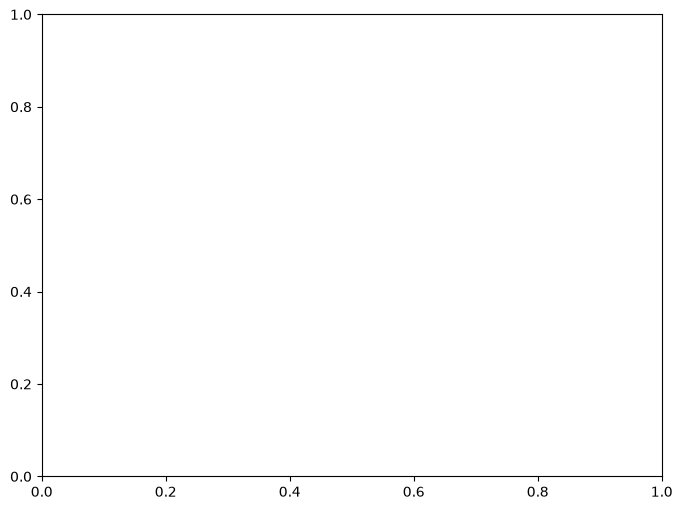

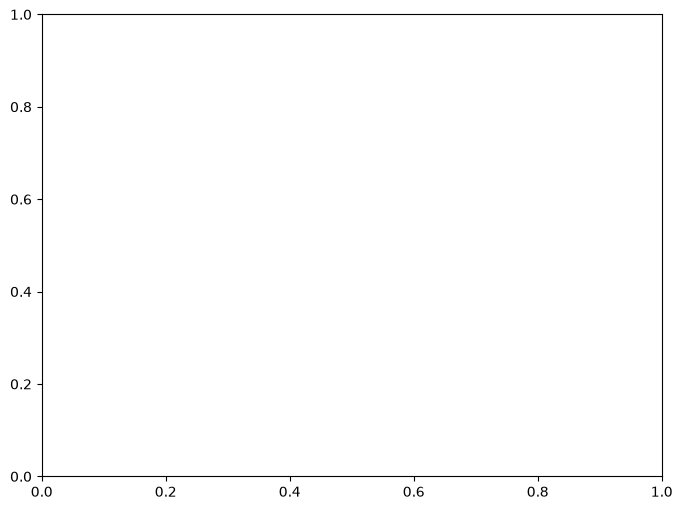

In [11]:

#=================
n_bags=0
param_grids = {
    "Random Forest":{
        'n_estimators':[100],
        'max_depth': [10, 20],
        #'min_samples_split':[2, 5],
        #'class_weight':['balanced']
        },
    "XGBoost":{
        'n_estimators':[150, 200, 300],
        'max_depth':[4, 5, 6],
        'learning_rate':[0.1]
       # 'subample':[0.8],
        #'colsample_bytree':[0.8]
        },
    "LightGBM":{
        'learning_rate': 0.05, 
        'max_depth': 10, 
        'n_estimators': 200
        #'verbose':[-1]
    }
}
base_models = {
    "Random Forest":RandomForestClassifier(random_state=42),
    #"XGBoost":xgb.XGBClassifier(random_state=42),
    "LightGBM":lgb.LGBMClassifier(random_state = 42)
} 

threshold = 0.85
results =[]
#fig_cm, axes_cm = plt.subplots(2, 3, figsize=(15, 9))
fig_roc, ax_roc = plt.subplots(figsize=(8,6))
fig_prc, ax_prc = plt.subplots(figsize=(8,6)) # calculate PR-AUC / AP
best_fitted_models = {}
best_params_dict = {}
best_score_dict = {}
threshold_list= np.arange(0.5, 0.951, 0.01)
for idx, (name, base_clf) in enumerate(base_models.items()):


   # base_clf.fit(X_sub, y_sub)

    #best_params= grid_search.best_params_
    #best_params_dict[name] = grid_search.best_params_
    #best_score_dict[name] = grid_search.best_score_
    
    #print(f"Best parameter combination: {best_params}")
    best_std_clf = clone(base_clf)
   # best_std_clf.set_params(**best_params)
    best_std_clf.fit(X_train_final, y_train)

    best_fitted_models[name] = best_std_clf
    y_prob_std= best_std_clf.predict_proba(X_test_final)[:, 1]

    for threshold in threshold_list:
        y_pred_std = (y_prob_std >= threshold).astype(int)

        auc_std = roc_auc_score(y_test, y_prob_std)
        pr_auc_std = average_precision_score(y_test, y_prob_std)


        

        results.append({
            "Model":name, "Type":"Standard", "Threshold":threshold,"Bag":n_bags,
            "ROC-AUC": round(auc_std, 4),
            "PR-AUC": round(pr_auc_std, 4),
            "Precision": round(precision_score(y_test, y_pred_std, zero_division=0), 4),
            "Recall": round(recall_score(y_test, y_pred_std, zero_division=0), 4),
            "F1-Score": round(f1_score(y_test, y_pred_std, zero_division=0), 4)
        })
    prec_std, rec_std, _ = precision_recall_curve(y_test, y_prob_std)
    ax_prc.plot(rec_std, prec_std, label=f'{name} (Standard) - PR-AUC: {pr_auc_std:.3f}')

    fpr_std, tpr_std, _ = roc_curve(y_test, y_prob_std)
    ax_roc.plot(fpr_std, tpr_std, label=f"{name} (Standard) - AUC: {auc_std:.3f}")

        #cm = confusion_matrix(y_test, y_pred_std)
        #sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes_cm[0, idx], cbar=False, xticklabels=['Pred:0','Pred:1'], yticklabels=['True:0', 'True:1'])

        #axes_cm[0, idx].set_title(f"{name} (Standard)")
        #axes_cm[0, idx].set_xlabel(f"Predicted Label")
        #axes_cm[0, idx].set_ylabel(f"True Label")

    #============= Pu model
    bag_list = [5, 10, 15, 30, 35]
    for n_bags in bag_list:
        pu_clf= bagging_rf(n_bags,clone(best_std_clf), X_train_final, y_train)
        y_prob_pu = predict_proba_pu(pu_clf, X_test_final)
        for threshold in threshold_list:
            y_pred_pu = (y_prob_pu >= threshold).astype(int)

            auc_pu = roc_auc_score(y_test, y_prob_pu)
            pr_auc_pu = average_precision_score(y_test, y_prob_pu)
            
            results.append({
                "Model": name, "Type": "PU Learning", "Threshold":threshold,"Bag":n_bags,
                "ROC-AUC": round(auc_pu, 4),
                "PR-AUC":round (pr_auc_pu, 4),
                "Precision": round(precision_score(y_test, y_pred_pu, zero_division=0), 4),
                "Recall": round(recall_score(y_test, y_pred_pu, zero_division=0), 4),
                "F1-Score": round(f1_score(y_test, y_pred_pu, zero_division=0 ), 4)
            })

        fpr_pu, tpr_pu, _ = roc_curve(y_test, y_prob_pu)
        ax_roc.plot(fpr_pu, tpr_pu, linestyle='--', label=f'{name} (PU) - AUC: {auc_pu: .3f}_bags={n_bags}')

        prec_pu, rec_pu, _ = precision_recall_curve(y_test, y_prob_pu)
        ax_prc.plot(rec_pu, prec_pu, linestyle='--', label=f'{name} (PU) - PU-AUC:{pr_auc_pu: .3f}_bags={n_bags}')

    #cm = confusion_matrix(y_test, y_pred_pu)
    #sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes_cm[1, idx], cbar=False, xticklabels=['Pred:0','Pred:1'], yticklabels=['True:0', 'True:1'])
    #xes_cm[1, idx].set_title(f"{name} (PU)")
    #axes_cm[1, idx].set_xlabel("Predicted Label")
    #axes_cm[1, idx].set_ylabel("True Label")

ax_roc.plot([0, 1], [0,1], 'k--', alpha=0.5)
ax_roc.set_title("ROC CURVE: Standard vs PU learning")
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.legend()

fig_roc.tight_layout()
fig_roc.savefig("img/PU_ROC_Comparison_lightgb_bag_compar.png")



baseline_pr = np.sum(y_test == 1) / len(y_test)
ax_prc.axhline(y=baseline_pr, color='k', linestyle='--', alpha=0.5, label=f'Baseline ({baseline_pr:.3f})')
ax_prc.set_title("Precision-Recall Curve: Standard vs PU Learning")
ax_prc.set_xlabel("Recall")
ax_prc.set_ylabel("Precision")
ax_prc.legend()
fig_prc.tight_layout()
fig_prc.savefig("img/PU_PRC_Comparison_lightgbm_bag_compar.png")


#fig_cm.tight_layout()
#fig_cm.savefig("img/PU_Confusion_Matrix_Comparison_XGBOOST_bag_compar.png")


plt.show()


df_metrics = pd.DataFrame(results)
print(df_metrics.to_string(index=False))
df_metrics.to_csv("img/PU_vs_Standard_Metrics_lightgb_bag_compar.csv", index=False)
#===========Rf model 

### what if we put all features? 

In [ ]:
import  xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, average_precision_score, precision_recall_curve
from sklearn.base import clone
#=================
base_models = {
    "Random Forest":RandomForestClassifier(
    max_depth=20, n_estimators= 100,
    random_state=42
),
"XGBoost": xgb.XGBClassifier(
    learning_rate=0.1, max_depth=5, n_estimators= 200,
    random_state=42
),
"LightGBM":lgb.LGBMClassifier(
    random_state = 42,
)
} 
threshold = 0.8
results =[]
fig_cm, axes_cm = plt.subplots(2, 3, figsize=(15, 9))
fig_roc, ax_roc = plt.subplots(figsize=(8,6))
fig_prc, ax_prc = plt.subplots(figsize=(8,6)) # 計算 PR-AUC / AP


for idx, (name, base_clf) in enumerate(base_models.items()):
    std_clf = clone(base_clf)
    std_clf.fit(X_train_final, y_train)

    y_prob_std= std_clf.predict_proba(X_test_final)[:, 1]
    y_pred_std = (y_prob_std >= threshold).astype(int)

    auc_std = roc_auc_score(y_test, y_prob_std)
    pr_auc_std = average_precision_score(y_test, y_prob_std)

    prec_std, rec_std, _ = precision_recall_curve(y_test, y_prob_std)
    ax_prc.plot(rec_std, prec_std, label=f'{name} (Standard) - PR-AUC: {pr_auc_std:.3f}')
    

    results.append({
        "Model":name, "Type":"Standard", "Threshold":threshold,
        "ROC-AUC": round(auc_std, 4),
        "PR-AUC": round(pr_auc_std, 4),
        "Precision": round(precision_score(y_test, y_pred_std, zero_division=0), 4),
        "Recall": round(recall_score(y_test, y_pred_std, zero_division=0), 4),
        "F1-Score": round(f1_score(y_test, y_pred_std, zero_division=0), 4)
    })

    fpr_std, tpr_std, _ = roc_curve(y_test, y_prob_std)
    ax_roc.plot(fpr_std, tpr_std, label=f"{name} (Standard) - AUC: {auc_std:.3f}")

    cm = confusion_matrix(y_test, y_pred_std)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes_cm[0, idx], cbar=False, xticklabels=['Pred:0','Pred:1'], yticklabels=['True:0', 'True:1'])

    axes_cm[0, idx].set_title(f"{name} (Standard)")
    axes_cm[0, idx].set_xlabel(f"Predicted Label")
    axes_cm[0, idx].set_ylabel(f"True Label")

    #============= Pu model
    n_bags= 30
    pu_clf= bagging_rf(n_bags,clone(base_clf), X_train_final, y_train)

    y_prob_pu = predict_proba_pu(pu_clf, X_test_final)
    y_pred_pu = (y_prob_pu >= threshold).astype(int)

    auc_pu = roc_auc_score(y_test, y_prob_pu)
    pr_auc_pu = average_precision_score(y_test, y_prob_pu)
    
    results.append({
        "Model": name, "Type": "PU Learning", "Threshold":threshold,
        "ROC-AUC": round(auc_pu, 4),
        "PR-AUC":round (pr_auc_pu, 4),
        "Precision": round(precision_score(y_test, y_pred_pu, zero_division=0), 4),
        "Recall": round(recall_score(y_test, y_pred_pu, zero_division=0), 4),
        "F1-Score": round(f1_score(y_test, y_pred_pu, zero_division=0 ), 4)
    })

    fpr_pu, tpr_pu, _ = roc_curve(y_test, y_prob_pu)
    ax_roc.plot(fpr_pu, tpr_pu, linestyle='--', label=f'{name} (PU) - AUC: {auc_pu: .3f}')

    prec_pu, rec_pu, _ = precision_recall_curve(y_test, y_prob_pu)
    ax_prc.plot(rec_pu, prec_pu, linestyle='--', label=f'{name} (PU) - PU-AUC:{pr_auc_pu: .3f}')

    cm = confusion_matrix(y_test, y_pred_pu)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes_cm[1, idx], cbar=False, xticklabels=['Pred:0','Pred:1'], yticklabels=['True:0', 'True:1'])
    axes_cm[1, idx].set_title(f"{name} (PU)")
    axes_cm[1, idx].set_xlabel("Predicted Label")
    axes_cm[1, idx].set_ylabel("True Label")

ax_roc.plot([0, 1], [0,1], 'k--', alpha=0.5)
ax_roc.set_title("ROC CURVE: Standard vs PU learning")
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.legend()

fig_roc.tight_layout()
fig_roc.savefig("img/PU_ROC_Comparison_best_param_30bags_v1.png")



baseline_pr = np.sum(y_test == 1) / len(y_test)
ax_prc.axhline(y=baseline_pr, color='k', linestyle='--', alpha=0.5, label=f'Baseline ({baseline_pr:.3f})')
ax_prc.set_title("Precision-Recall Curve: Standard vs PU Learning")
ax_prc.set_xlabel("Recall")
ax_prc.set_ylabel("Precision")
ax_prc.legend()
fig_prc.tight_layout()
fig_prc.savefig("img/PU_PRC_Comparison_best_param_30bags_v1.png")


fig_cm.tight_layout()
fig_cm.savefig("img/PU_Confusion_Matrix_Comparison_best_param_30bags_v1.png")


plt.show()


df_metrics = pd.DataFrame(results)
print(df_metrics.to_string(index=False))
df_metrics.to_csv("img/PU_vs_Standard_Metrics_best_param_30bags_v1.csv", index=False)
#===========

In [ ]:
import  xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, average_precision_score, precision_recall_curve
from sklearn.base import clone
#=================
base_models = {
    "Random Forest":RandomForestClassifier(
    random_state=42
),
"XGBoost": xgb.XGBClassifier(
    random_state=42
),
"LightGBM":lgb.LGBMClassifier(
    random_state = 42,
)
} 
threshold = 0.8
results =[]
fig_cm, axes_cm = plt.subplots(2, 3, figsize=(15, 9))
fig_roc, ax_roc = plt.subplots(figsize=(8,6))
fig_prc, ax_prc = plt.subplots(figsize=(8,6)) # 計算 PR-AUC / AP


for idx, (name, base_clf) in enumerate(base_models.items()):
    std_clf = clone(base_clf)
    std_clf.fit(X_train_final, y_train)

    y_prob_std= std_clf.predict_proba(X_test_final)[:, 1]
    y_pred_std = (y_prob_std >= threshold).astype(int)

    auc_std = roc_auc_score(y_test, y_prob_std)
    pr_auc_std = average_precision_score(y_test, y_prob_std)

    prec_std, rec_std, _ = precision_recall_curve(y_test, y_prob_std)
    ax_prc.plot(rec_std, prec_std, label=f'{name} (Standard) - PR-AUC: {pr_auc_std:.3f}')
    

    results.append({
        "Model":name, "Type":"Standard", "Threshold":threshold,
        "ROC-AUC": round(auc_std, 4),
        "PR-AUC": round(pr_auc_std, 4),
        "Precision": round(precision_score(y_test, y_pred_std, zero_division=0), 4),
        "Recall": round(recall_score(y_test, y_pred_std, zero_division=0), 4),
        "F1-Score": round(f1_score(y_test, y_pred_std, zero_division=0), 4)
    })

    fpr_std, tpr_std, _ = roc_curve(y_test, y_prob_std)
    ax_roc.plot(fpr_std, tpr_std, label=f"{name} (Standard) - AUC: {auc_std:.3f}")

    cm = confusion_matrix(y_test, y_pred_std)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes_cm[0, idx], cbar=False, xticklabels=['Pred:0','Pred:1'], yticklabels=['True:0', 'True:1'])

    axes_cm[0, idx].set_title(f"{name} (Standard)")
    axes_cm[0, idx].set_xlabel(f"Predicted Label")
    axes_cm[0, idx].set_ylabel(f"True Label")

    #============= Pu model
    n_bags= 30
    pu_clf= bagging_rf(n_bags,clone(base_clf), X_train_final, y_train)

    y_prob_pu = predict_proba_pu(pu_clf, X_test_final)
    y_pred_pu = (y_prob_pu >= threshold).astype(int)

    auc_pu = roc_auc_score(y_test, y_prob_pu)
    pr_auc_pu = average_precision_score(y_test, y_prob_pu)
    
    results.append({
        "Model": name, "Type": "PU Learning", "Threshold":threshold,
        "ROC-AUC": round(auc_pu, 4),
        "PR-AUC":round (pr_auc_pu, 4),
        "Precision": round(precision_score(y_test, y_pred_pu, zero_division=0), 4),
        "Recall": round(recall_score(y_test, y_pred_pu, zero_division=0), 4),
        "F1-Score": round(f1_score(y_test, y_pred_pu, zero_division=0 ), 4)
    })

    fpr_pu, tpr_pu, _ = roc_curve(y_test, y_prob_pu)
    ax_roc.plot(fpr_pu, tpr_pu, linestyle='--', label=f'{name} (PU) - AUC: {auc_pu: .3f}')

    prec_pu, rec_pu, _ = precision_recall_curve(y_test, y_prob_pu)
    ax_prc.plot(rec_pu, prec_pu, linestyle='--', label=f'{name} (PU) - PU-AUC:{pr_auc_pu: .3f}')

    cm = confusion_matrix(y_test, y_pred_pu)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes_cm[1, idx], cbar=False, xticklabels=['Pred:0','Pred:1'], yticklabels=['True:0', 'True:1'])
    axes_cm[1, idx].set_title(f"{name} (PU)")
    axes_cm[1, idx].set_xlabel("Predicted Label")
    axes_cm[1, idx].set_ylabel("True Label")

ax_roc.plot([0, 1], [0,1], 'k--', alpha=0.5)
ax_roc.set_title("ROC CURVE: Standard vs PU learning")
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.legend()

fig_roc.tight_layout()
fig_roc.savefig("img/PU_ROC_Comparison.png")



baseline_pr = np.sum(y_test == 1) / len(y_test)
ax_prc.axhline(y=baseline_pr, color='k', linestyle='--', alpha=0.5, label=f'Baseline ({baseline_pr:.3f})')
ax_prc.set_title("Precision-Recall Curve: Standard vs PU Learning")
ax_prc.set_xlabel("Recall")
ax_prc.set_ylabel("Precision")
ax_prc.legend()
fig_prc.tight_layout()
fig_prc.savefig("img/PU_PRC_Comparison.png")


fig_cm.tight_layout()
fig_cm.savefig("img/PU_Confusion_Matrix_Comparison.png")


plt.show()


df_metrics = pd.DataFrame(results)
print(df_metrics.to_string(index=False))
df_metrics.to_csv("img/PU_vs_Standard_Metrics.csv", index=False)
#===========

In [10]:
ax_roc.plot([0, 1], [0,1], 'k--', alpha=0.5)
ax_roc.set_title("ROC CURVE: Standard vs PU learning")
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.legend()

fig_roc.tight_layout()
fig_roc.savefig("img/PU_ROC_Comparison.png")



baseline_pr = np.sum(y_test == 1) / len(y_test)
ax_prc.axhline(y=baseline_pr, color='k', linestyle='--', alpha=0.5, label=f'Baseline ({baseline_pr:.3f})')
ax_prc.set_title("Precision-Recall Curve: Standard vs PU Learning")
ax_prc.set_xlabel("Recall")
ax_prc.set_ylabel("Precision")
ax_prc.legend()
fig_prc.tight_layout()
fig_prc.savefig("img/PU_PRC_Comparison.png")


fig_cm.tight_layout()
fig_cm.savefig("img/PU_Confusion_Matrix_Comparison.png")


plt.show()


df_metrics = pd.DataFrame(results)
print(df_metrics.to_string(index=False))
df_metrics.to_csv("img/PU_vs_Standard_Metrics.csv", index=False)
#===========

        Model        Type  Threshold  ROC-AUC  PR-AUC  Precision  Recall  F1-Score
Random Forest    Standard        0.9   0.9661  0.8413     0.9813  0.3010    0.4607
Random Forest PU Learning        0.9   0.9467  0.7438     0.9067  0.4082    0.5630
      XGBoost    Standard        0.9   0.9337  0.7600     0.9521  0.3970    0.5604
      XGBoost PU Learning        0.9   0.9373  0.7556     0.8067  0.5764    0.6724
     LightGBM    Standard        0.9   0.9622  0.8240     0.9680  0.3274    0.4893
     LightGBM PU Learning        0.9   0.9456  0.7604     0.8449  0.5184    0.6426


=======================================================================================================================================================

#============ threshold